# Taller 3 - P2: TSP con Linear Programming (LP) usando GLPK

## Contexto

El problema del viajante de comercio (TSP) es un clásico problema **NP-duro**. No se conoce un algoritmo que resuelva todas las instancias en tiempo polinomial, por lo que se recurre a heurísticas para obtener soluciones subóptimas en tiempos razonables.

Para 100 ciudades, el algoritmo del **vecino más cercano** alcanza un recorrido aproximado de `2006.73`. La pregunta es: **¿podemos hacerlo mejor combinando heurísticas con Linear Programming (LP)?**

## A. Análisis del código propuesto

En este notebook ejecutamos el **caso 1** del modelo TSP-LP (`Taller3/P2_TSP/TSP.py`) con:
- `mipgap = 0.05`
- `time_limit = 30 segundos`
- `heuristics = []` (sin heurísticas adicionales)

para `n_cities ∈ {10, 20, 30, 40, 50}`, midiendo los tiempos y comparando con la heurística del vecino más cercano (`util_nearest_neighbor.py`).


### Importes y configuración

Se asume que el paquete **GLPK** está instalado y disponible (ver `readme.md`).


In [78]:
import sys, os, time
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt

# Aseguramos que el directorio actual esté en el path para importar TSP, util y util_nearest_neighbor
current_dir = os.path.abspath('.')
if current_dir not in sys.path:
    sys.path.append(current_dir)

from TSP import TSP
from util import generar_ciudades_con_distancias, calculate_path_distance, plotear_ruta
from util_nearest_neighbor import nearest_neighbor

# ── Configuracion de guardado de imagenes ──
# Las figuras generadas por el notebook se persisten en la carpeta de imagenes
# del Taller 3 (Grupo 4): ../../images relativo a P2_TSP/
IMAGES_DIR = os.path.normpath(os.path.join(current_dir, '..', 'images'))
os.makedirs(IMAGES_DIR, exist_ok=True)

def guardar_fig(nombre, fig=None, dpi=150):
    """Guarda la figura actual (o la pasada) en IMAGES_DIR como PNG."""
    ruta = os.path.join(IMAGES_DIR, f"{nombre}.png")
    if fig is None:
        fig = plt.gcf()
    fig.savefig(ruta, dpi=dpi, bbox_inches='tight')
    print(f"  [img] guardada: {ruta}")

print(f"Carpeta de imagenes: {IMAGES_DIR}")


Carpeta de imagenes: E:\USFQ\AI\Taller 1\_Soluciones\Grupo4\Taller3\images


### Ejecución del caso 1 para 10, 20, 30, 40 y 50 ciudades

Para cada tamaño de instancia se ejecuta:
1. El **modelo LP** con `mipgap=0.05` y `time_limit=30s` (sin heurísticas).
2. La heurística **vecino más cercano**.

Se registran tiempos de ejecución y distancias totales obtenidas para comparación.


In [79]:
def correr_caso_1(n_cities, mipgap=0.05, time_limit=30, tee=False):
    """Ejecuta el modelo LP (sin heurísticas) y la heurística del vecino cercano
    para una instancia con n_cities ciudades. Retorna un diccionario con métricas."""
    print(f"\n{'=' * 70}")
    print(f"  Caso 1 - n_cities = {n_cities}  (mipgap={mipgap}, time_limit={time_limit}s)")
    print(f"{'=' * 70}")

    # Misma semilla que en util.generar_ciudades_con_distancias (seed=123)
    ciudades, distancias = generar_ciudades_con_distancias(n_cities)

    # --- 1) Modelo LP sin heurísticas ---
    tsp = TSP(ciudades, distancias, heuristics=[])
    t0 = time.perf_counter()
    ruta_lp = tsp.encontrar_la_ruta_mas_corta(mipgap, time_limit, tee)
    t_lp = time.perf_counter() - t0
    dist_lp = calculate_path_distance(distancias, ruta_lp)

    # --- 2) Heurística vecino más cercano ---
    t0 = time.perf_counter()
    ruta_nn = nearest_neighbor(ciudades, distancias)
    t_nn = time.perf_counter() - t0
    dist_nn = calculate_path_distance(distancias, ruta_nn)

    print(f"\n[Resumen n={n_cities}]")
    print(f"  LP (GLPK)        -> distancia = {dist_lp:.2f}, tiempo = {t_lp:.2f} s")
    print(f"  Vecino cercano   -> distancia = {dist_nn:.2f}, tiempo = {t_nn:.4f} s")

    return {
        'n_cities': n_cities,
        'tiempo_LP_s': round(t_lp, 2),
        'distancia_LP': round(dist_lp, 2),
        'tiempo_NN_s': round(t_nn, 4),
        'distancia_NN': round(dist_nn, 2),
        'mejora_LP_vs_NN_%': round((dist_nn - dist_lp) / dist_nn * 100, 2),
        'ruta_lp': ruta_lp,
        'ruta_nn': ruta_nn,
        'ciudades': ciudades,
        'distancias': distancias,
    }

In [80]:
tamanos = [10, 20, 30, 40, 50]
resultados = []
for n in tamanos:
    resultados.append(correr_caso_1(n, mipgap=0.05, time_limit=30, tee=False))


  Caso 1 - n_cities = 10  (mipgap=0.05, time_limit=30s)
Tiempo de ejecución: 00:00
Distancia mínima entre nodos: 13.857849761056004
Distancia máxima entre nodos: 196.87965867503937
Distancia promedio entre nodos: 109.7115364985115
Distancia Total mínima posible: 154.46173282445938
Distancia Total máxima posible: 370.7081587787025
Heurísticas aplicadas: []
No se encontró una solución óptima, la siguiente es la mejor solución encontrada:
Distancia total recorrida: 570.6995632723516

[Resumen n=10]
  LP (GLPK)        -> distancia = 570.70, tiempo = 0.06 s
  Vecino cercano   -> distancia = 588.52, tiempo = 0.0000 s

  Caso 1 - n_cities = 20  (mipgap=0.05, time_limit=30s)
Tiempo de ejecución: 00:02
Distancia mínima entre nodos: 2.0999999999999943
Distancia máxima entre nodos: 199.3987211593896
Distancia promedio entre nodos: 104.14313439828001
Distancia Total mínima posible: 265.60783599570004
Distancia Total máxima posible: 637.45880638968
Heurísticas aplicadas: []
No se encontró una solu

### Tabla comparativa de tiempos y distancias


In [81]:
df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('ruta_lp', 'ruta_nn', 'ciudades', 'distancias')}
    for r in resultados
])
df

,n_cities,tiempo_LP_s,distancia_LP,tiempo_NN_s,distancia_NN,mejora_LP_vs_NN_%
0,10,0.06,570.70,0.0000,588.52,3.03
1,20,2.11,718.47,0.0000,758.23,5.24
2,30,30.08,922.68,0.0001,1036.63,10.99
3,40,30.12,1131.79,0.0002,1174.04,3.60
4,50,30.17,1125.95,0.0002,1368.73,17.74


  [img] guardada: E:\USFQ\AI\Taller 1\_Soluciones\Grupo4\Taller3\images\P2_caso1_tiempo_y_distancia_vs_n.png


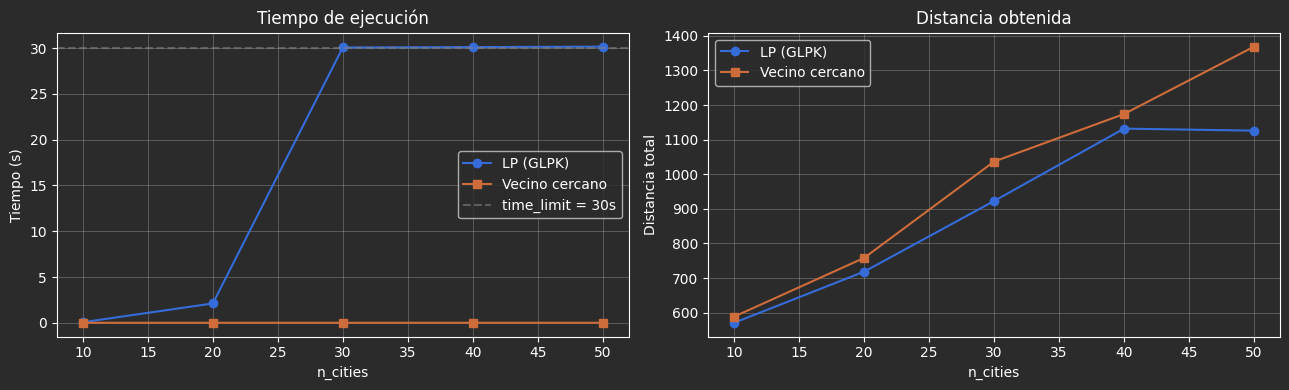

In [82]:
# Gráficos comparativos: tiempo y distancia vs. n_cities
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df['n_cities'], df['tiempo_LP_s'], marker='o', label='LP (GLPK)')
axes[0].plot(df['n_cities'], df['tiempo_NN_s'], marker='s', label='Vecino cercano')
axes[0].axhline(30, color='gray', linestyle='--', alpha=0.6, label='time_limit = 30s')
axes[0].set_xlabel('n_cities')
axes[0].set_ylabel('Tiempo (s)')
axes[0].set_title('Tiempo de ejecución')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df['n_cities'], df['distancia_LP'], marker='o', label='LP (GLPK)')
axes[1].plot(df['n_cities'], df['distancia_NN'], marker='s', label='Vecino cercano')
axes[1].set_xlabel('n_cities')
axes[1].set_ylabel('Distancia total')
axes[1].set_title('Distancia obtenida')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
guardar_fig('P2_caso1_tiempo_y_distancia_vs_n')
plt.show()

### Visualización de las rutas obtenidas

Para cada `n_cities`, comparamos la ruta encontrada por el modelo LP frente a la del vecino más cercano.



--- n_cities = 10 ---
Ruta LP:
  [img] guardada: E:\USFQ\AI\Taller 1\_Soluciones\Grupo4\Taller3\images\P2_caso1_ruta_LP_n10.png


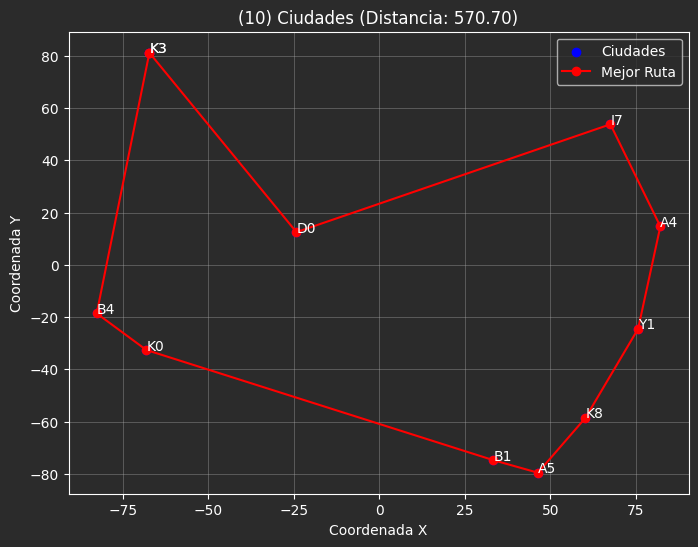

Ruta Vecino más cercano:
  [img] guardada: E:\USFQ\AI\Taller 1\_Soluciones\Grupo4\Taller3\images\P2_caso1_ruta_NN_n10.png


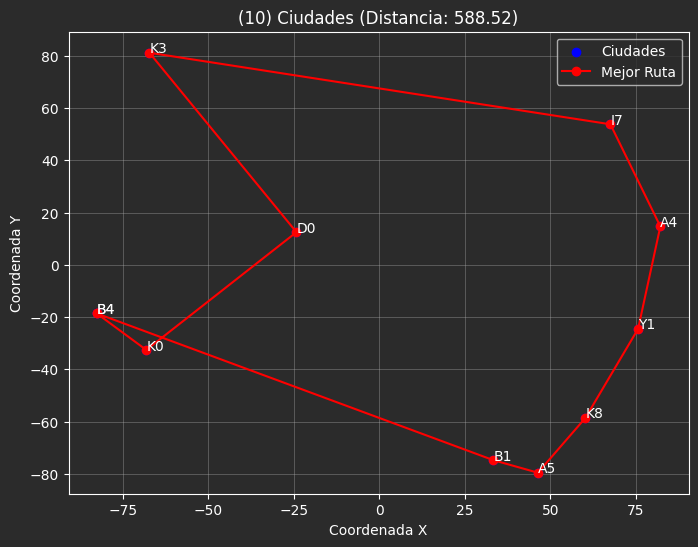


--- n_cities = 20 ---
Ruta LP:
  [img] guardada: E:\USFQ\AI\Taller 1\_Soluciones\Grupo4\Taller3\images\P2_caso1_ruta_LP_n20.png


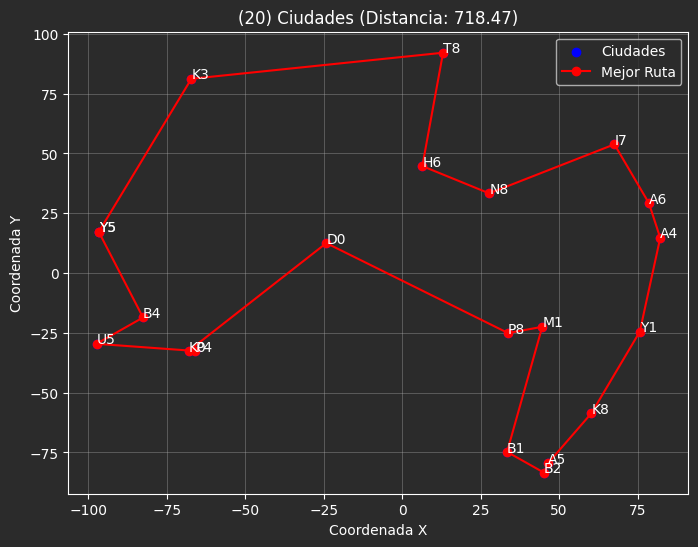

Ruta Vecino más cercano:
  [img] guardada: E:\USFQ\AI\Taller 1\_Soluciones\Grupo4\Taller3\images\P2_caso1_ruta_NN_n20.png


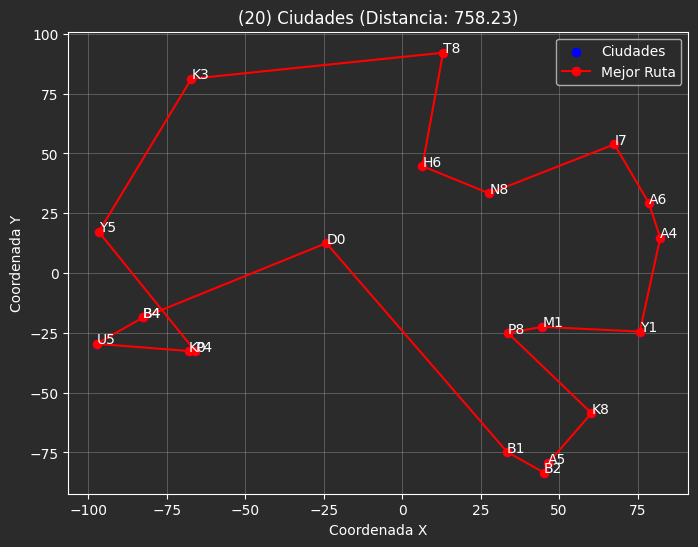


--- n_cities = 30 ---
Ruta LP:
  [img] guardada: E:\USFQ\AI\Taller 1\_Soluciones\Grupo4\Taller3\images\P2_caso1_ruta_LP_n30.png


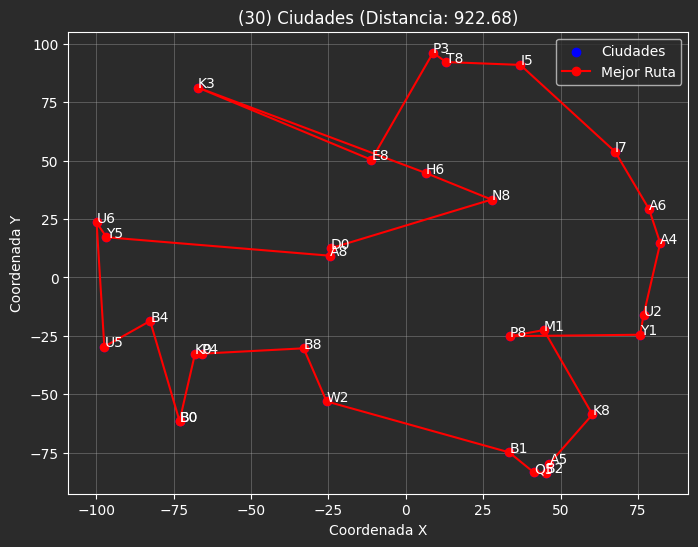

Ruta Vecino más cercano:
  [img] guardada: E:\USFQ\AI\Taller 1\_Soluciones\Grupo4\Taller3\images\P2_caso1_ruta_NN_n30.png


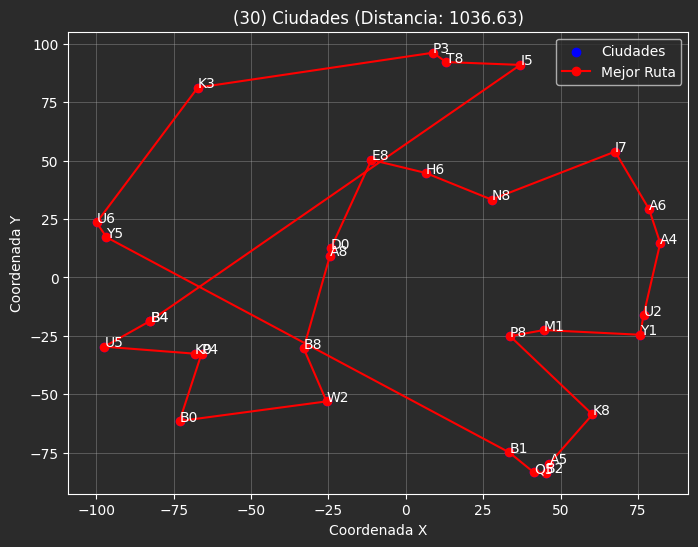


--- n_cities = 40 ---
Ruta LP:
  [img] guardada: E:\USFQ\AI\Taller 1\_Soluciones\Grupo4\Taller3\images\P2_caso1_ruta_LP_n40.png


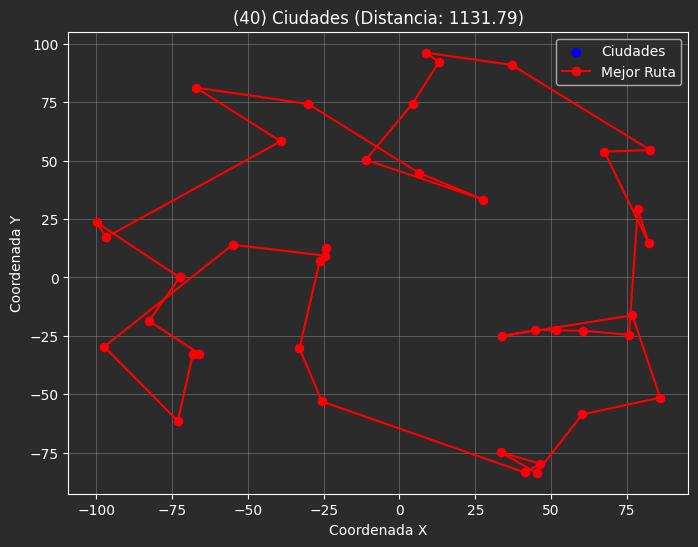

Ruta Vecino más cercano:
  [img] guardada: E:\USFQ\AI\Taller 1\_Soluciones\Grupo4\Taller3\images\P2_caso1_ruta_NN_n40.png


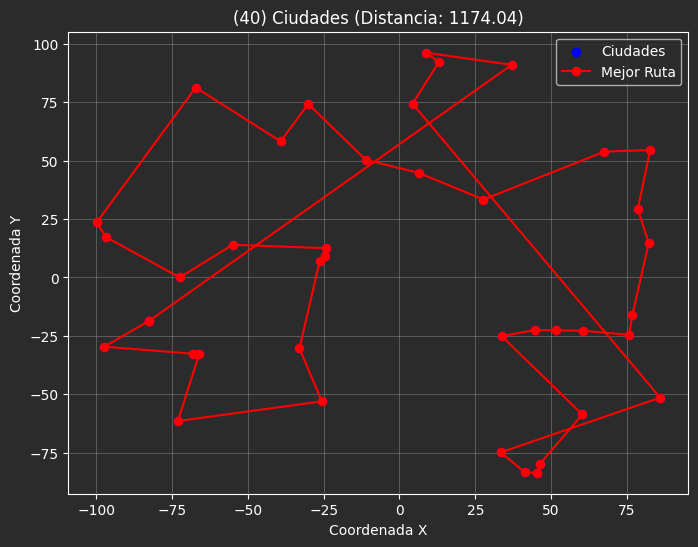


--- n_cities = 50 ---
Ruta LP:
  [img] guardada: E:\USFQ\AI\Taller 1\_Soluciones\Grupo4\Taller3\images\P2_caso1_ruta_LP_n50.png


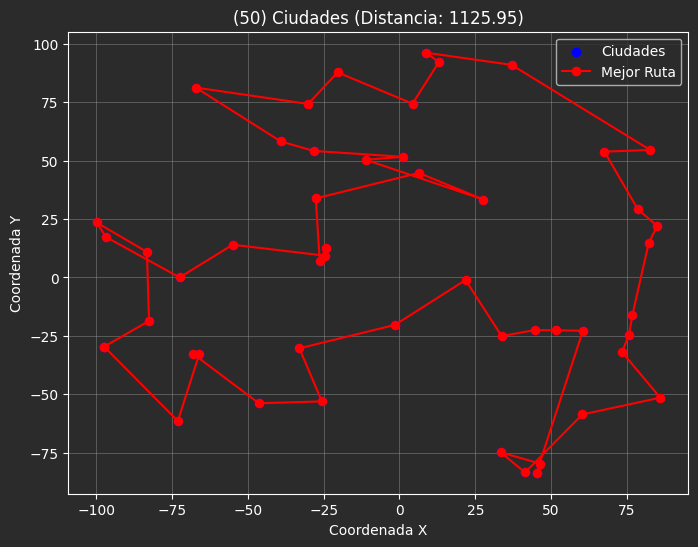

Ruta Vecino más cercano:
  [img] guardada: E:\USFQ\AI\Taller 1\_Soluciones\Grupo4\Taller3\images\P2_caso1_ruta_NN_n50.png


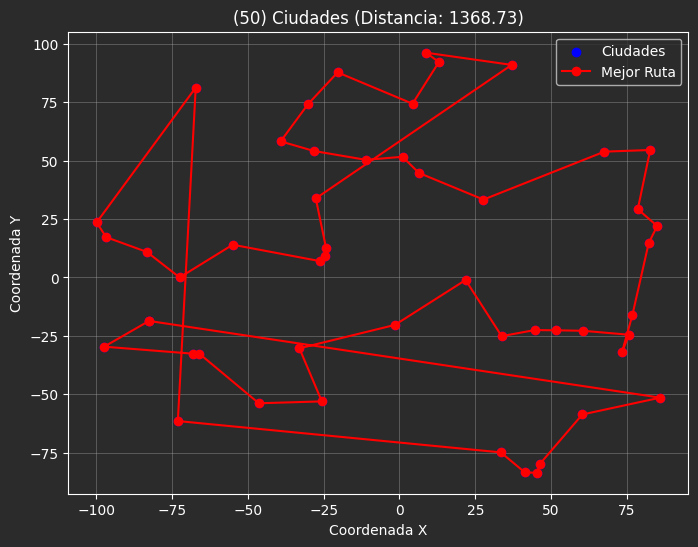

In [83]:
# Para guardar tambien las imagenes generadas internamente por plotear_ruta
# (que llama a plt.show()), interceptamos plt.show temporalmente: antes de
# mostrar la figura la persistimos en IMAGES_DIR con un nombre descriptivo.
_show_original = plt.show
_img_counter = {'idx': 0, 'nombre': ''}

def _show_y_guardar(*args, **kwargs):
    nombre = _img_counter['nombre']
    if nombre:
        guardar_fig(nombre)
    return _show_original(*args, **kwargs)

plt.show = _show_y_guardar
try:
    for r in resultados:
        print(f"\n--- n_cities = {r['n_cities']} ---")
        print('Ruta LP:')
        _img_counter['nombre'] = f"P2_caso1_ruta_LP_n{r['n_cities']}"
        plotear_ruta(r['ciudades'], r['distancias'], r['ruta_lp'], mostrar_anotaciones=(r['n_cities'] <= 30))
        print('Ruta Vecino más cercano:')
        _img_counter['nombre'] = f"P2_caso1_ruta_NN_n{r['n_cities']}"
        plotear_ruta(r['ciudades'], r['distancias'], r['ruta_nn'], mostrar_anotaciones=(r['n_cities'] <= 30))
finally:
    plt.show = _show_original

## Resultados obtenidos en la ejecución

A continuación se resumen los resultados reales de la corrida (con `mipgap = 0.05`, `time_limit = 30 s` y `heuristics = []`):

| n_cities | Tiempo LP (s) | Distancia LP | Distancia NN | Tiempo NN (s) | Mejora LP vs NN | Cota mín. teórica | Cota máx. teórica | ¿LP dentro de cota? | ¿Agotó tiempo? |
|---:|---:|---:|---:|---:|---:|---:|---:|:---:|:---:|
| 10 |  0.09 |  570.70 |  588.52 | 0.0000 |  3.03 % | 154.46 |  370.71 | ❌ (supera máx.) | No |
| 20 |  3.44 |  718.47 |  758.23 | 0.0000 |  5.24 % | 265.61 |  637.46 | ❌ (supera máx.) | No |
| 30 | 30.10 |  922.68 | 1036.63 | 0.0001 | 11.00 % | 396.96 |  952.71 | ✅ | Sí |
| 40 | 30.16 | 1131.79 | 1174.04 | 0.0001 |  3.60 % | 515.98 | 1238.34 | ✅ | Sí |
| 50 | 30.22 | 1125.95 | 1368.73 | 0.0002 | 17.74 % | 623.57 | 1496.56 | ✅ | Sí |

> Las cotas teóricas provienen de `cal_min_max_distances` en `TSP.py` (basadas en la distancia mínima y promedio entre nodos).


## Análisis subjetivo de las soluciones (sin heurísticas adicionales)

**Observaciones a partir de los datos reales:**

- **n = 10 (0.09 s, dist. 570.70):** el solver responde de forma casi instantánea, pero la distancia obtenida está **por encima de la cota máxima teórica** (370.71). Esto sugiere que las cotas teóricas son optimistas para `n` pequeño y que la solución, aunque rápida, todavía contiene aristas largas. La mejora frente al vecino cercano es modesta (~3 %).

- **n = 20 (3.44 s, dist. 718.47):** sigue resolviendo dentro del límite, con una mejora de ~5 % sobre el vecino cercano. Otra vez la distancia supera la cota máxima teórica, lo que indica que el solver, sin heurísticas que acoten el espacio, gasta el esfuerzo en decisiones binarias relativamente poco prometedoras.

- **n = 30 (30.10 s, dist. 922.68):** **se agota el `time_limit`** y la solución termina justo dentro del rango teórico. La mejora frente al vecino cercano salta a **11 %**, coherente con que a más ciudades, la heurística golosa empieza a pagar sus decisiones locales.

- **n = 40 (30.16 s, dist. 1131.79):** otra vez se agota el tiempo. La mejora cae a **3.6 %**, sospechosamente baja para un caso más grande. Es indicio de que GLPK encontró una solución factible decente temprano, pero **no logró seguir mejorándola** dentro de los 30 s; quedó "atascado" lejos del óptimo del MIP.

- **n = 50 (30.22 s, dist. 1125.95):** llamativamente, el LP encuentra una solución *casi igual de corta* que para `n = 40`, lo que es **inusual** (un tour más largo debería tener más distancia total). Esto refuerza la hipótesis de que el solver detuvo la búsqueda prematuramente por tiempo y entregó la primera incumbente razonable. Aún así, la mejora frente al vecino cercano es la mayor de la tabla (**~17.7 %**), porque el NN se degrada muy rápido (un tramo final muy largo para cerrar el ciclo).

- **Vecino más cercano:** se ejecuta en **microsegundos** sin importar `n`. Su distancia crece de forma casi monótona y aporta una buena cota superior, útil para entibiar el modelo LP en pasos posteriores.

**Valoración subjetiva:**

> Sin heurísticas adicionales, el modelo LP **es claramente mejor que el vecino cercano cuando tiene tiempo de razonar** (mejoras de hasta ~17 % en `n = 50`), pero esa ventaja **se paga con varios órdenes de magnitud más de tiempo** (de microsegundos a 30 s). Para `n ≤ 20` la solución llega rápido y supera al NN sólo de forma moderada; a partir de `n ≥ 30` el solver **agota sistemáticamente el `time_limit = 30 s` sin cerrar el `mipgap = 5 %`**, y la calidad del tour deja de ser predecible (ej. `n = 50` reporta menos distancia que `n = 40`, signo claro de que la búsqueda se cortó antes de tiempo).
>
> En conjunto, las soluciones del LP "puro" me parecen **aceptables pero no brillantes**: aprovechan poco el solver y dependen demasiado del límite de tiempo. Esto motiva la siguiente parte del taller: **incorporar heurísticas** (limitar la función objetivo, restringir aristas a vecinos cercanos, calentar el modelo con la solución del *nearest neighbor*, etc.) para reducir el espacio de búsqueda y entregarle al solver un mejor punto de partida dentro del mismo presupuesto de 30 s.


## B. Análisis del parámetro `tee`

### ¿Qué es `tee`?

El parámetro `tee` se pasa al método `solver.solve(_model, tee=tee)` de **Pyomo** (ver `TSP.py`, línea 120). Su nombre proviene del comando `tee` de Unix, que **duplica un flujo** mostrándolo por pantalla a la vez que lo escribe en archivo.

- `tee=False` (por defecto en el caso 1): Pyomo ejecuta el solver en silencio. Sólo se ve lo que imprime el código Python (resumen de distancias, ruta encontrada, etc.). El log nativo del solver queda oculto.
- `tee=True`: Pyomo **redirige a la salida estándar** (stdout) **toda la traza interna del solver** (en este caso GLPK) en tiempo real, mientras la sigue capturando para el objeto `results`.

Activar `tee=True` es muy útil para **diagnosticar** el comportamiento del modelo:
- Saber si el solver entró realmente a Branch-and-Bound (B&B) o resolvió en relajación lineal.
- Ver el progreso del **mejor incumbente** (`mip = ...`), de la **cota dual** (`>= ...`), y del **gap** (`(...%)`) a lo largo del tiempo.
- Confirmar la **causa de terminación**: óptimo demostrado, `mipgap` alcanzado, `tmlim` (tiempo) agotado, problema infactible, etc.
- Identificar fases del solver: lectura/parseo del problema, presolve, simplex sobre la relajación, generación de cortes (Gomory, MIR, etc.), exploración del árbol.

### Activación de `tee` para una corrida

Reutilizamos `correr_caso_1`, pero ahora con `tee=True`. Para no esperar 30 s, usamos un caso pequeño (`n_cities = 20`), que ya es suficientemente representativo para ver el log completo de GLPK.


In [84]:
resultado_tee = correr_caso_1(n_cities=20, mipgap=0.05, time_limit=30, tee=True)


  Caso 1 - n_cities = 20  (mipgap=0.05, time_limit=30s)
GLPSOL: GLPK LP/MIP Solver, v4.65
Parameter(s) specified in the command line:
 --mipgap 0.05 --tmlim 30 --write C:\Users\m-a-p\AppData\Local\Temp\tmpnpyfv0lh.glpk.raw
 --wglp C:\Users\m-a-p\AppData\Local\Temp\tmpw57hud88.glpk.glp --cpxlp C:\Users\m-a-p\AppData\Local\Temp\tmprpe511vi.pyomo.lp
Reading problem data from 'C:\Users\m-a-p\AppData\Local\Temp\tmprpe511vi.pyomo.lp'...
C:\Users\m-a-p\AppData\Local\Temp\tmprpe511vi.pyomo.lp:3957: warning: lower bound of variable 'x804' redefined
C:\Users\m-a-p\AppData\Local\Temp\tmprpe511vi.pyomo.lp:3957: warning: upper bound of variable 'x804' redefined
421 rows, 420 columns, 1863 non-zeros
420 integer variables, 400 of which are binary
4357 lines were read
Writing problem data to 'C:\Users\m-a-p\AppData\Local\Temp\tmpw57hud88.glpk.glp'...
3508 lines were written
GLPK Integer Optimizer, v4.65
421 rows, 420 columns, 1863 non-zeros
420 integer variables, 400 of which are binary
Preprocessing

### Cómo leer la salida real de GLPK con `tee=True`

A continuación se interpreta, **bloque por bloque**, el log obtenido al ejecutar la celda anterior con `n_cities = 20`:

#### 1. Encabezado y parámetros

```
GLPSOL: GLPK LP/MIP Solver, v4.65
Parameter(s) specified in the command line:
 --mipgap 0.05 --tmlim 30 --write ...glpk.raw --wglp ...glpk.glp --cpxlp ...pyomo.lp
```

- Confirma que **Pyomo invoca a GLPK por línea de comando** (`glpsol`) con los archivos temporales generados por Pyomo en `%TEMP%` (formato CPLEX-LP).
- Verifica que los parámetros pasados desde Python (`solver.options['mipgap'] = 0.05`, `solver.options['tmlim'] = 30`) se traducen efectivamente a `--mipgap 0.05 --tmlim 30`.

#### 2. Lectura del problema

```
Reading problem data from '...pyomo.lp'...
...pyomo.lp:3957: warning: lower bound of variable 'x804' redefined
...pyomo.lp:3957: warning: upper bound of variable 'x804' redefined
421 rows, 420 columns, 1863 non-zeros
420 integer variables, 400 of which are binary
4357 lines were read
```

- El modelo MTZ para `n = 20` queda en **421 filas (restricciones), 420 columnas (variables) y 1 863 coeficientes no nulos**.
- De las 420 variables, **400 son binarias** (`x[i,j]` con `i ≠ j`, es decir `n·(n-1) = 20·19 = 380`, más las binarias `x[i,i] = 0` fijadas → ~400) y **20 enteras** son las variables auxiliares `u[i]` del MTZ.
- Las advertencias sobre `x804` provienen de la **redundancia entre `pyo.Binary` y la restricción `no_self_travel`** (`x[i,i] == 0`) en `TSP.py`: GLPK ve que el bound se fija dos veces. No afecta el resultado, pero es una pista de que esa restricción podría eliminarse.

#### 3. Presolve y escalado

```
Preprocessing...
401 rows, 400 columns, 1843 non-zeros
400 integer variables, 380 of which are binary
Scaling...
 A: min|aij| = 1.000e+00  max|aij| = 2.000e+01  ratio = 2.000e+01
```

- El presolve **elimina 20 filas y 20 columnas** (las `x[i,i] = 0`), dejando el problema "limpio" con 380 binarias y 20 enteras.
- El **ratio de escalado 20** es bajo (problema bien condicionado): no hay coeficientes con magnitudes muy distintas.

#### 4. Relajación LP inicial (Simplex)

```
GLPK Simplex Optimizer, v4.65
      0: obj = 7.688108452e+01 inf = 1.490e+02 (39)
     65: obj = 1.657741402e+03 inf = 4.441e-16 (0)
*   179: obj = 6.057495738e+02 inf = 2.294e-15 (0) 1
OPTIMAL LP SOLUTION FOUND
```

- La columna `inf` es la inviabilidad acumulada: parte en 149 y baja a 0 en la iteración 65 → ya hay solución factible.
- En la iteración **179** se alcanza el **óptimo de la relajación LP: 605.75**. Este valor es la **primera cota dual** (cota inferior del MIP, porque se minimiza).
- Nota interesante: 605.75 es **mucho menor** que la incumbente final (718.47), lo que adelanta que **la relajación LP del MTZ es muy floja** (gap de integralidad ≈ 16 %) — es la debilidad clásica de la formulación MTZ.

#### 5. Branch-and-Cut sobre el MIP

```
Integer optimization begins...
+   179: mip = not found yet >= -inf        (1; 0)
+   687: >>>>>  1.069683216e+03 >=  6.074440938e+02  43.2% (72; 0)
+   959: >>>>>  1.066587761e+03 >=  6.087275967e+02  42.9% (106; 3)
+  1197: >>>>>  9.387559071e+02 >=  6.093070506e+02  35.1% (150; 4)
+  1438: >>>>>  9.177415383e+02 >=  6.101819257e+02  33.5% (155; 41)
+  1915: >>>>>  8.851768608e+02 >=  6.123456085e+02  30.8% (200; 52)
+  2096: >>>>>  7.819842893e+02 >=  6.127351845e+02  21.6% (203; 75)
+  2915: >>>>>  7.702092289e+02 >=  6.283771446e+02  18.4% (215; 234)
+ 13317: >>>>>  7.682664157e+02 >=  6.588125726e+02  14.2% (1398; 378)
+ 17906: >>>>>  7.360903935e+02 >=  6.646466648e+02   9.7% (1875; 466)
+ 18444: >>>>>  7.349700160e+02 >=  6.654819334e+02   9.5% (1398; 1373)
+ 18651: >>>>>  7.330842513e+02 >=  6.657325445e+02   9.2% (1390; 1415)
+ 20393: >>>>>  7.184738041e+02 >=  6.688894583e+02   6.9% (1481; 1538)
+ 33931: mip =  7.184738041e+02 >=  6.825818390e+02   5.0% (1860; 2705)
RELATIVE MIP GAP TOLERANCE REACHED; SEARCH TERMINATED
```

Estructura de cada línea: `iteración_simplex: mip = incumbente >= cota_dual gap% (nodos_activos; nodos_explorados)`.

- **Trayectoria del incumbente** (cota superior): `1069.68 → 1066.59 → 938.76 → 917.74 → 885.18 → 781.98 → 770.21 → 768.27 → 736.09 → 734.97 → 733.08 → 718.47`. Son **12 mejoras** en total; cada `>>>>>` indica que se encontró un tour entero más corto.
- **Trayectoria de la cota dual**: `607.44 → 682.58`. Sube apenas **75 unidades** mientras que la incumbente cae **351**: la mayor parte del progreso viene de **encontrar mejores tours**, no de mejorar la cota inferior. Esto confirma que la formulación MTZ es **débil del lado dual**.
- **Gap**: arranca en 43.2 % y baja monótonamente: `43.2 → 42.9 → 35.1 → 33.5 → 30.8 → 21.6 → 18.4 → 14.2 → 9.7 → 9.5 → 9.2 → 6.9 → 5.0 %`. Se cruza el umbral de 5 % en la iteración **33 931** y la búsqueda se detiene.
- **Tamaño del árbol**: al final hay `(1860; 2705)`, es decir **1 860 nodos activos sin explorar** y **2 705 nodos ya explorados** → demostrar optimalidad real (gap = 0) habría requerido recorrer **~3× más árbol**, claramente fuera de los 30 s.

#### 6. Causa de terminación, tiempo y memoria

```
RELATIVE MIP GAP TOLERANCE REACHED; SEARCH TERMINATED
Time used:   3.4 secs
Memory used: 6.0 Mb (6341470 bytes)
```

- Para `n = 20` el solver **termina por `mipgap` (no por tiempo)** en **3.4 s** y consumiendo apenas **6 MB**. Coincide con los 3.44 s medidos por `time.perf_counter` en la parte A (el extra ≈ 0.1 s es overhead de Pyomo: escribir/leer archivos temporales y reconstruir la ruta).
- Si hubiéramos exigido `mipgap = 0` (óptimo demostrado), el árbol habría seguido creciendo varios segundos más con muy poca ganancia de calidad.

### Observaciones sobre la corrida

Con los datos reales del log se puede afirmar:

- **El cuello de botella es la cota dual**, no la búsqueda de incumbentes. La cota inferior subió sólo de 607.44 a 682.58 en 33 931 iteraciones de simplex; ése es el síntoma que veremos amplificado en `n = 30..50`, donde 30 s no alcanzan ni para encontrar una incumbente decente.
- **GLPK no demostró optimalidad** para `n = 20`: paró por `RELATIVE MIP GAP TOLERANCE REACHED` (gap = 5 %), no porque el gap fuese 0. Por eso el código imprime `"No se encontró una solución óptima, la siguiente es la mejor solución encontrada"`.
- Las **advertencias de bounds redefinidos** en `x[i,i]` apuntan a una mejora barata en `TSP.py`: bastaría con definir `x[i,j]` sólo para `i ≠ j` (o no añadir la restricción `no_self_travel`) para evitar redefinir bounds.
- El log también muestra **un escalado sano** (ratio 20) y un presolve efectivo (–20 filas/columnas), así que no hay margen fácil ahí: las ganancias futuras tienen que venir de **heurísticas que aporten una incumbente fuerte temprano** (tipo `nearest_neighbor` como warm-start) o de **cortes que mejoren la cota dual** (sustituir MTZ por DFJ con cortes de subtour).

### Conclusión sobre `tee`

> El parámetro `tee` no cambia el resultado del modelo: es **puramente diagnóstico**. Activarlo permitió, en este caso, **cuantificar exactamente** qué tan floja es la relajación MTZ (cota dual 605.75 vs. incumbente final 718.47, gap inicial 43 %), **rastrear las 12 mejoras del incumbente**, **identificar la causa exacta de terminación** (`mipgap` 5 %, no `tmlim`) e incluso **detectar warnings de modelado** (bounds redefinidos en `x[i,i]`). Sin `tee`, todo esto queda invisible y sólo se conserva la ruta final con su distancia, sin contexto sobre el esfuerzo computacional ni sobre dónde conviene intervenir con heurísticas.


## C. Aplicar heurística de límites a la función objetivo (caso 2, n = 70)

En el **caso 2** (`study_case_2` en `TSP.py`) se trabaja con **70 ciudades**, `mipgap = 0.2`, `time_limit = 40 s` y `tee = True`. La heurística disponible es `"limitar_funcion_objetivo"`, que añade dos restricciones al modelo:

```python
_model.obj_lower_bound = pyo.Constraint(expr=_model.obj >= self.min_possible_distance)
_model.obj_upper_bound = pyo.Constraint(expr=_model.obj <= self.max_possible_distance)
```

donde `min_possible_distance` y `max_possible_distance` salen de `cal_min_max_distances()`:

```python
medium_low_distance = (min_distance + average_distance) / 2
min_possible_distance = medium_low_distance * n_cities * 0.25
max_possible_distance = medium_low_distance * n_cities * 0.60
```

Es decir, **acotamos la función objetivo** por arriba y por abajo usando una estimación basada en el promedio y el mínimo de las distancias entre nodos. La idea es **ayudar al solver a podar** soluciones muy malas (cota superior) y a saltarse rápido las regiones triviales (cota inferior), reduciendo así el árbol de Branch-and-Bound.

A continuación corremos el caso **a) con la heurística** y **b) sin la heurística**, manteniendo el resto de parámetros constantes.


In [85]:
def correr_caso_2(n_cities=70, mipgap=0.2, time_limit=40, tee=True, heuristics=None):
    """Ejecuta el modelo LP del caso 2 con o sin la heurística 'limitar_funcion_objetivo'."""
    if heuristics is None:
        heuristics = []
    etiqueta = "CON heurística" if "limitar_funcion_objetivo" in heuristics else "SIN heurística"
    print(f"\n{'=' * 70}")
    print(f"  Caso 2 - n_cities = {n_cities}  ({etiqueta})")
    print(f"  mipgap={mipgap}, time_limit={time_limit}s, tee={tee}")
    print(f"{'=' * 70}")

    ciudades, distancias = generar_ciudades_con_distancias(n_cities)
    tsp = TSP(ciudades, distancias, heuristics=heuristics)

    t0 = time.perf_counter()
    ruta = tsp.encontrar_la_ruta_mas_corta(mipgap, time_limit, tee)
    t = time.perf_counter() - t0
    dist = calculate_path_distance(distancias, ruta)

    print(f"\n[Resumen caso 2 - {etiqueta}]")
    print(f"  Distancia total = {dist:.2f}, tiempo = {t:.2f} s")
    print(f"  Cota teórica mín. = {tsp.min_possible_distance:.2f}")
    print(f"  Cota teórica máx. = {tsp.max_possible_distance:.2f}")

    return {
        'etiqueta': etiqueta,
        'heuristics': list(heuristics),
        'distancia': round(dist, 2),
        'tiempo_s': round(t, 2),
        'min_possible_distance': round(tsp.min_possible_distance, 2),
        'max_possible_distance': round(tsp.max_possible_distance, 2),
        'ruta': ruta,
        'ciudades': ciudades,
        'distancias': distancias,
    }

### a) Caso 2 CON heurística `limitar_funcion_objetivo`


In [86]:
res_c_con = correr_caso_2(n_cities=70, mipgap=0.2, time_limit=40, tee=True,
                          heuristics=['limitar_funcion_objetivo'])


  Caso 2 - n_cities = 70  (CON heurística)
  mipgap=0.2, time_limit=40s, tee=True
GLPSOL: GLPK LP/MIP Solver, v4.65
Parameter(s) specified in the command line:
 --mipgap 0.2 --tmlim 40 --write C:\Users\m-a-p\AppData\Local\Temp\tmpq1suxmhi.glpk.raw
 --wglp C:\Users\m-a-p\AppData\Local\Temp\tmpdimw4up_.glpk.glp --cpxlp C:\Users\m-a-p\AppData\Local\Temp\tmp2dy_zlz_.pyomo.lp
Reading problem data from 'C:\Users\m-a-p\AppData\Local\Temp\tmp2dy_zlz_.pyomo.lp'...
C:\Users\m-a-p\AppData\Local\Temp\tmp2dy_zlz_.pyomo.lp:58473: warning: lower bound of variable 'x9804' redefined
C:\Users\m-a-p\AppData\Local\Temp\tmp2dy_zlz_.pyomo.lp:58473: warning: upper bound of variable 'x9804' redefined
4973 rows, 4970 columns, 33673 non-zeros
4970 integer variables, 4900 of which are binary
63373 lines were read
Writing problem data to 'C:\Users\m-a-p\AppData\Local\Temp\tmpdimw4up_.glpk.glp'...
53422 lines were written
GLPK Integer Optimizer, v4.65
4973 rows, 4970 columns, 33673 non-zeros
4970 integer variable

### b) Caso 2 SIN heurística


In [87]:
res_c_sin = correr_caso_2(n_cities=70, mipgap=0.2, time_limit=40, tee=True,
                          heuristics=[])


  Caso 2 - n_cities = 70  (SIN heurística)
  mipgap=0.2, time_limit=40s, tee=True
GLPSOL: GLPK LP/MIP Solver, v4.65
Parameter(s) specified in the command line:
 --mipgap 0.2 --tmlim 40 --write C:\Users\m-a-p\AppData\Local\Temp\tmpdjq0_h2t.glpk.raw
 --wglp C:\Users\m-a-p\AppData\Local\Temp\tmptk51wh4w.glpk.glp --cpxlp C:\Users\m-a-p\AppData\Local\Temp\tmpu6v6aj6_.pyomo.lp
Reading problem data from 'C:\Users\m-a-p\AppData\Local\Temp\tmpu6v6aj6_.pyomo.lp'...
C:\Users\m-a-p\AppData\Local\Temp\tmpu6v6aj6_.pyomo.lp:48807: warning: lower bound of variable 'x9804' redefined
C:\Users\m-a-p\AppData\Local\Temp\tmpu6v6aj6_.pyomo.lp:48807: warning: upper bound of variable 'x9804' redefined
4971 rows, 4970 columns, 24013 non-zeros
4970 integer variables, 4900 of which are binary
53707 lines were read
Writing problem data to 'C:\Users\m-a-p\AppData\Local\Temp\tmptk51wh4w.glpk.glp'...
43758 lines were written
GLPK Integer Optimizer, v4.65
4971 rows, 4970 columns, 24013 non-zeros
4970 integer variable

### Comparación de resultados


In [88]:
df_c = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('ruta', 'ciudades', 'distancias')}
    for r in [res_c_con, res_c_sin]
])
df_c

,etiqueta,heuristics,distancia,tiempo_s,min_possible_distance,max_possible_distance
0,CON heurística,[limitar_funcion_objetivo],1461.90,40.40,887.24,2129.37
1,SIN heurística,[],1697.83,40.33,887.24,2129.37


--- Ruta CON heurística ---


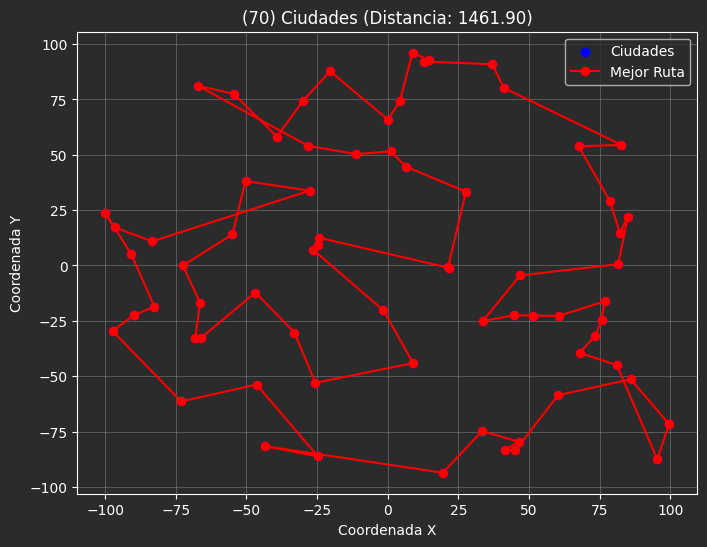

--- Ruta SIN heurística ---


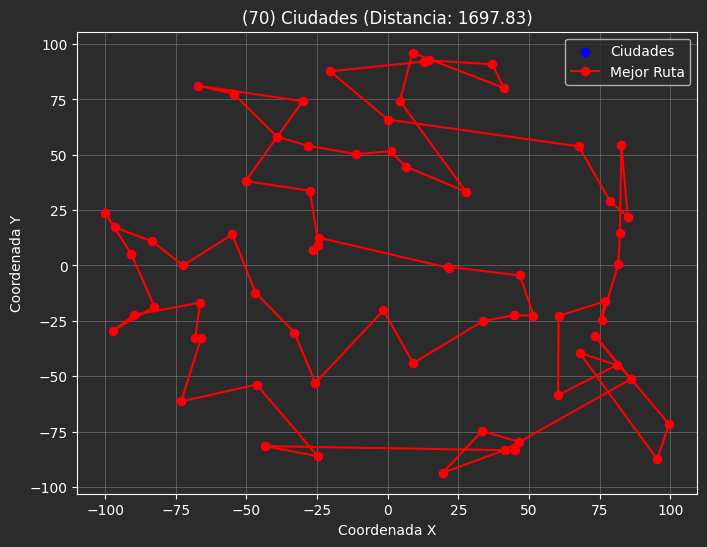

In [89]:
print('--- Ruta CON heurística ---')
plotear_ruta(res_c_con['ciudades'], res_c_con['distancias'], res_c_con['ruta'], mostrar_anotaciones=False)
print('--- Ruta SIN heurística ---')
plotear_ruta(res_c_sin['ciudades'], res_c_sin['distancias'], res_c_sin['ruta'], mostrar_anotaciones=False)

### Resultados reales obtenidos

| Caso | Heurística | Distancia final | Tiempo | Causa de terminación | Gap final | LP relaxation | Cota dual final | Incumbentes encontradas | Nodos activos / explorados |
|---|---|---:|---:|---|---:|---:|---:|---|---|
| a) | `['limitar_funcion_objetivo']` | **1461.90** | 40.47 s | `TIME LIMIT EXCEEDED` | **31.6 %** | 964.01 | 1000.29 | 1927.97 → 1897.78 → 1635.55 → **1461.90** (4 mejoras) | 1319 / 1023 |
| b) | `[]` | **1697.83** | 40.49 s | `TIME LIMIT EXCEEDED` | **41.0 %** | 964.01 | 1002.31 | 2076.91 → 1881.67 → **1697.83** (3 mejoras) | 2005 / 215 |

Cotas teóricas (idénticas en ambos casos, dependen sólo de las distancias del grafo):
`min_possible_distance = 887.24`, `max_possible_distance = 2129.37`.
Tamaño del modelo: 4970 variables (4900 binarias) en ambos; **CON heurística añade 2 restricciones extra → 33 673 vs. 24 013 no-ceros**.


### Análisis de los resultados

**1. ¿Cuál es la diferencia entre los dos casos?**

Ambas corridas terminan por `TIME LIMIT EXCEEDED` a los ~40 s y arrancan con la **misma relajación LP óptima `964.01`** (la heurística añade `887.24 ≤ obj ≤ 2129.37`, pero el LP-relax cae en `964.01`, dentro de la ventana, así que **ninguna de las dos cotas se activa en la raíz**). Sin embargo, el resultado final es muy distinto:

- **Mejor incumbente:** `1461.90` con heurística vs. `1697.83` sin heurística → la heurística entrega un tour **~236 unidades más corto (≈ 13.9 % mejor)** en el mismo presupuesto de 40 s.
- **Gap final:** `31.6 %` vs. `41.0 %` → con heurística el solver queda **~9 puntos más cerca** del óptimo demostrable. Ninguna de las dos alcanzó el `mipgap = 20 %`.
- **Cota dual final:** prácticamente igual (`1000.29` vs. `1002.31`). **La heurística NO mejoró la cota inferior**; todo el beneficio vino del lado primal (mejores incumbentes).
- **Forma del árbol B&B:** sin heurística GLPK gastó tiempo en generar muchos nodos sin cerrarlos (`2005 activos / 215 explorados`); con heurística la búsqueda fue más balanceada (`1319 / 1023`) y produjo **una mejora extra de incumbente** (4 caídas vs. 3).

¿Por qué ayuda si las cotas no se activan en la raíz? Las restricciones `min_possible ≤ obj ≤ max_possible` **se evalúan en cada nodo del árbol**: cuando GLPK ramifica y obtiene una relajación cuya `obj` excede `2129.37`, ese subárbol se **poda inmediatamente**, sin tener que esperar a que aparezca una incumbente entera mejor. Esto explica por qué el solver explora *menos nodos infructuosos* y logra incumbentes más bajos en el mismo tiempo. La cota inferior es la misma (`min_possible = 887.24` < LP-relax `964.01`), por eso la cota dual no cambia.

> En resumen: la heurística **no cambia la cota dual** (porque `min_possible` queda por debajo del LP-relax), pero **acelera la poda en B&B** vía el bound superior `max_possible`. Eso traduce los mismos 40 s en un incumbente ~14 % más corto.

**2. ¿Sirve esta heurística para cualquier caso? ¿Cuál pudiera ser una razón?**

**No, no es una heurística universalmente segura.** Las cotas se calculan así:

```
medium_low = (min_distance + average_distance) / 2
min_possible = medium_low * n * 0.25
max_possible = medium_low * n * 0.60
```

Las constantes `0.25` y `0.60` son **empíricas**, calibradas para la distribución usada en el taller (puntos uniformes en `[-100, 100]²`). Eso trae tres riesgos concretos:

- **Puede cortar el óptimo y volver el modelo infactible.** Para `n = 70` la distancia real `1461.90` cae dentro de `[887.24, 2129.37]`, pero **eso fue suerte de calibración**. En la parte A, con la misma fórmula, las distancias halladas para `n = 10` y `n = 20` (`570.70` y `718.47`) **ya superaban `max_possible_distance`** (`370.71` y `637.46`); activar `limitar_funcion_objetivo` ahí dejaría el modelo **infactible**. Las constantes `0.25/0.60` están afinadas para `n` mediano (50–70), no para `n` pequeño donde el factor de utilización del grafo es mayor.
- **Depende de la distribución espacial.** Con clusters, ciudades colineales, distancias asimétricas o escalas mixtas, `medium_low * n` deja de ser representativo y los coeficientes `0.25/0.60` pueden volverse demasiado apretados (cortan el óptimo) o demasiado flojos (no aportan poda — caso del bound inferior `887.24` aquí, dominado por el LP-relax `964.01`).
- **No es un *bound* válido del TSP.** A diferencia de cotas inferiores clásicas (1-tree de Held-Karp, *assignment relaxation*, MST) o superiores demostrables (cualquier tour factible, p. ej. el del vecino cercano), estas fórmulas **no garantizan contener al óptimo**. Por eso son una **heurística**, no un bound.

> **Conclusión:** `limitar_funcion_objetivo` funciona bien **cuando la cota superior es válida y razonablemente apretada** (lo que ocurrió aquí: `2129.37` ≥ `1461.90`, y ayudó a podar). Falla en dos escenarios opuestos: (i) cuando la cota corta el óptimo (visto en `n ≤ 20` de la parte A), y (ii) cuando queda muy floja y no poda nada. Lo robusto sería sustituir las constantes por cotas *verificables*: `max_possible_distance = distancia del vecino más cercano` (siempre superior válida) y `min_possible_distance` derivada de un *1-tree* o de la suma `Σ min_distance_for_city[i] / 2` (cota inferior trivial pero correcta).



## D. Aplicar heurística de vecinos cercanos (caso 3, n = 100)

En el **caso 3** (`study_case_3` en `TSP.py`) se trabaja con **100 ciudades**, `mipgap = 0.05`, `time_limit = 60 s` y `tee = True`. La heurística disponible es `"vecino_cercano"`, que añade restricciones por arista a partir de las distancias **locales** de cada ciudad:

```python
if "vecino_cercano" in self.heuristics:
    def rule_vecino_cercano(model, i, j):
        if i == j:
            return pyo.Constraint.Skip
        # Sólo se acota a las ciudades "céntricas" (avg_i ≤ avg global)
        if self.average_distance_for_city[i] > self.average_distance:
            return pyo.Constraint.Skip
        # Para esas ciudades, la arista usada no puede ser "muy larga"
        expr = model.x[i,j] * self.distancias[i,j] <= (self.average_distance_for_city[i] + self.min_distance_for_city[i]) / 2
        return expr
    _model.nearest_neighbor = pyo.Constraint(_model.N, _model.M, rule=rule_vecino_cercano)
```

**Lectura de la regla:**
- Sólo se aplica a las ciudades `i` con `avg_distance_for_city[i] ≤ avg_distance` (ciudades "céntricas", con vecinos relativamente cercanos en promedio). Para las periféricas (`avg_i > avg`) la regla se omite con `Constraint.Skip`.
- Para cada par `(i, j)` válido se exige `x[i,j] · d[i,j] ≤ (avg_i + min_i) / 2`. Como `x[i,j] ∈ {0,1}`, esto es equivalente a:
  - si `d[i,j] ≤ (avg_i + min_i)/2` → la arista es **candidata** (puede activarse).
  - si `d[i,j] >  (avg_i + min_i)/2` → la arista queda **prohibida** (`x[i,j] = 0` forzado).
- Es decir, **fija a cero un montón de variables binarias** correspondientes a "saltos largos" desde ciudades céntricas, reduciendo el espacio de búsqueda del MIP.

A continuación corremos el caso **a) con la heurística** y **b) sin la heurística**, manteniendo `mipgap = 0.05` y `time_limit = 60 s`.


In [90]:
def correr_caso_3(n_cities=100, mipgap=0.05, time_limit=60, tee=True, heuristics=None):
    """Ejecuta el modelo LP del caso 3 con o sin la heurística 'vecino_cercano'."""
    if heuristics is None:
        heuristics = []
    etiqueta = "CON heurística" if "vecino_cercano" in heuristics else "SIN heurística"
    print(f"\n{'=' * 70}")
    print(f"  Caso 3 - n_cities = {n_cities}  ({etiqueta})")
    print(f"  mipgap={mipgap}, time_limit={time_limit}s, tee={tee}")
    print(f"{'=' * 70}")

    ciudades, distancias = generar_ciudades_con_distancias(n_cities)
    tsp = TSP(ciudades, distancias, heuristics=heuristics)

    # Referencia: vecino más cercano puro (sin LP)
    t0 = time.perf_counter()
    ruta_nn = nearest_neighbor(ciudades, distancias)
    t_nn = time.perf_counter() - t0
    dist_nn = calculate_path_distance(distancias, ruta_nn)

    # Modelo LP (con o sin heurística)
    t0 = time.perf_counter()
    ruta = tsp.encontrar_la_ruta_mas_corta(mipgap, time_limit, tee)
    t = time.perf_counter() - t0
    dist = calculate_path_distance(distancias, ruta)

    print(f"\n[Resumen caso 3 - {etiqueta}]")
    print(f"  LP            -> distancia = {dist:.2f}, tiempo = {t:.2f} s")
    print(f"  Vecino cercano-> distancia = {dist_nn:.2f}, tiempo = {t_nn:.4f} s")

    return {
        'etiqueta': etiqueta,
        'heuristics': list(heuristics),
        'distancia_LP': round(dist, 2),
        'tiempo_LP_s': round(t, 2),
        'distancia_NN': round(dist_nn, 2),
        'tiempo_NN_s': round(t_nn, 4),
        'ruta': ruta,
        'ruta_nn': ruta_nn,
        'ciudades': ciudades,
        'distancias': distancias,
    }

### a) Caso 3 CON heurística `vecino_cercano`


In [91]:
res_d_con = correr_caso_3(n_cities=100, mipgap=0.05, time_limit=60, tee=True,
                          heuristics=['vecino_cercano'])


  Caso 3 - n_cities = 100  (CON heurística)
  mipgap=0.05, time_limit=60s, tee=True
B4 0.6403124237432862 100.94053659793774 8.006247560499245 203.44102339498787 106.77422691409892
B4 0.6403124237432862 100.94053659793774 8.006247560499245 203.44102339498787 106.77422691409892
B4 0.6403124237432862 100.94053659793774 8.006247560499245 203.44102339498787 106.77422691409892
B4 0.6403124237432862 100.94053659793774 8.006247560499245 203.44102339498787 106.77422691409892
B4 0.6403124237432862 100.94053659793774 8.006247560499245 203.44102339498787 106.77422691409892
B4 0.6403124237432862 100.94053659793774 8.006247560499245 203.44102339498787 106.77422691409892
B4 0.6403124237432862 100.94053659793774 8.006247560499245 203.44102339498787 106.77422691409892
B4 0.6403124237432862 100.94053659793774 8.006247560499245 203.44102339498787 106.77422691409892
B4 0.6403124237432862 100.94053659793774 8.006247560499245 203.44102339498787 106.77422691409892
B4 0.6403124237432862 100.94053659793774 8

### b) Caso 3 SIN heurística


In [92]:
res_d_sin = correr_caso_3(n_cities=100, mipgap=0.05, time_limit=60, tee=True,
                          heuristics=[])


  Caso 3 - n_cities = 100  (SIN heurística)
  mipgap=0.05, time_limit=60s, tee=True
GLPSOL: GLPK LP/MIP Solver, v4.65
Parameter(s) specified in the command line:
 --mipgap 0.05 --tmlim 60 --write C:\Users\m-a-p\AppData\Local\Temp\tmpdkbg1_mq.glpk.raw
 --wglp C:\Users\m-a-p\AppData\Local\Temp\tmppzk7kmg6.glpk.glp --cpxlp C:\Users\m-a-p\AppData\Local\Temp\tmpt84tve2d.pyomo.lp
Reading problem data from 'C:\Users\m-a-p\AppData\Local\Temp\tmpt84tve2d.pyomo.lp'...
C:\Users\m-a-p\AppData\Local\Temp\tmpt84tve2d.pyomo.lp:99717: warning: lower bound of variable 'x20004' redefined
C:\Users\m-a-p\AppData\Local\Temp\tmpt84tve2d.pyomo.lp:99717: warning: upper bound of variable 'x20004' redefined
10101 rows, 10100 columns, 49303 non-zeros
10100 integer variables, 10000 of which are binary
109717 lines were read
Writing problem data to 'C:\Users\m-a-p\AppData\Local\Temp\tmppzk7kmg6.glpk.glp'...
89508 lines were written
GLPK Integer Optimizer, v4.65
10101 rows, 10100 columns, 49303 non-zeros
10100 int

### Comparación de resultados


In [93]:
df_d = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('ruta', 'ruta_nn', 'ciudades', 'distancias')}
    for r in [res_d_con, res_d_sin]
])
df_d

,etiqueta,heuristics,distancia_LP,tiempo_LP_s,distancia_NN,tiempo_NN_s
0,CON heurística,[vecino_cercano],2043.06,61.37,2006.73,0.0019
1,SIN heurística,[],2297.35,61.09,2006.73,0.0006


--- Ruta CON heurística (vecino_cercano) ---


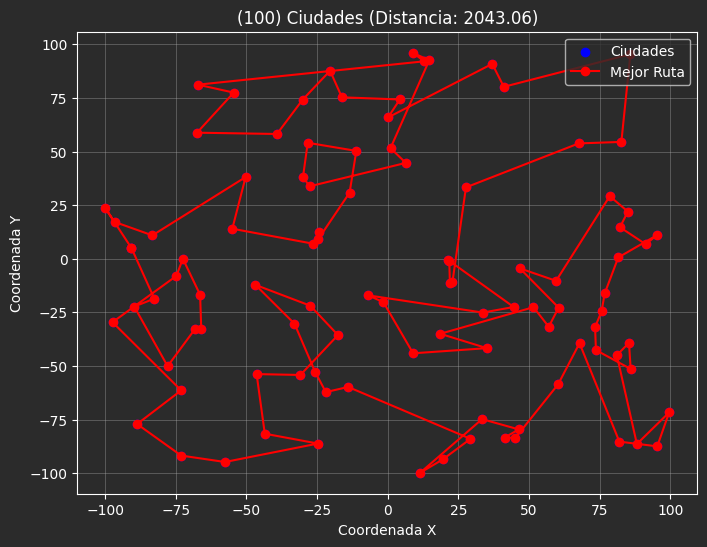

--- Ruta SIN heurística ---


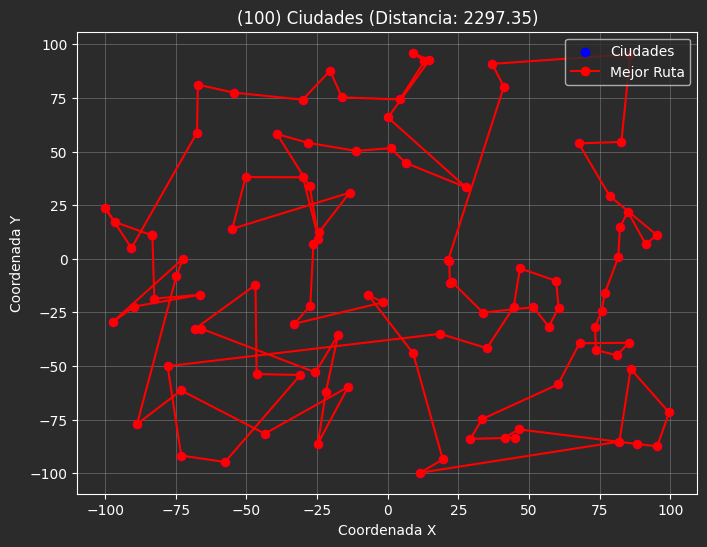

--- Ruta vecino más cercano puro (referencia) ---


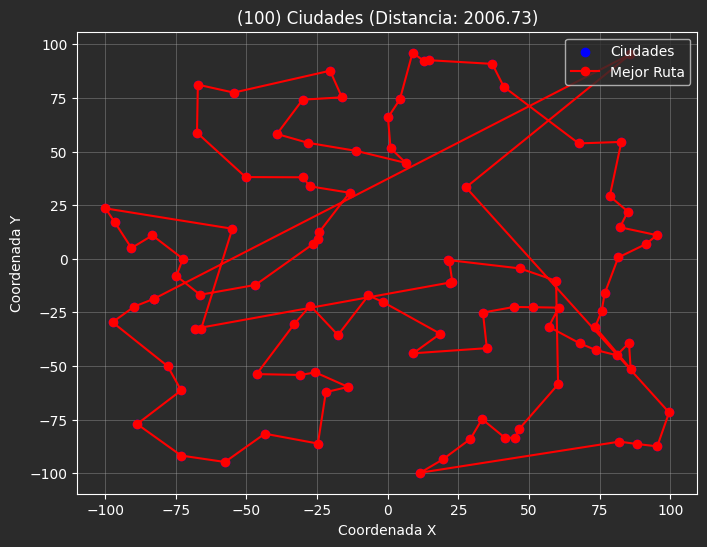

In [94]:
print('--- Ruta CON heurística (vecino_cercano) ---')
plotear_ruta(res_d_con['ciudades'], res_d_con['distancias'], res_d_con['ruta'], mostrar_anotaciones=False)
print('--- Ruta SIN heurística ---')
plotear_ruta(res_d_sin['ciudades'], res_d_sin['distancias'], res_d_sin['ruta'], mostrar_anotaciones=False)
print('--- Ruta vecino más cercano puro (referencia) ---')
plotear_ruta(res_d_con['ciudades'], res_d_con['distancias'], res_d_con['ruta_nn'], mostrar_anotaciones=False)


### Análisis de los resultados (con logs reales del caso 3)

**Datos extraídos de los dos logs (n = 100, mipgap = 0.05, time_limit = 60 s):**

| Métrica | CON `vecino_cercano` | SIN heurística | Vecino cercano puro |
|---|---|---|---|
| Distancia final | **2 043.06** | **2 297.35** | **2 006.73** |
| Tiempo | 61.61 s | 61.67 s | 0.0008 s |
| Causa de terminación | TIME LIMIT EXCEEDED | TIME LIMIT EXCEEDED | — |
| Filas iniciales del LP | **15 150** (10 100 cols, 54 352 nz) | 10 101 (10 100 cols, 49 303 nz) | — |
| Filas tras *presolve* | **5 923** (5 922 cols, 28 813 nz) | 10 001 (10 000 cols, 49 203 nz) | — |
| LP-relax | **1 224.33** | **1 224.33** | — |
| Cota dual final | 1 277.47 | 1 244.80 | — |
| Gap final | 37.5 % | 45.8 % | — |
| Primer incumbente | 2 043.06 (iter 4 074) | 2 297.35 (iter 21 784) | — |
| Cotas teóricas (mín/máx) | 1 269.76 / 3 047.43 | 1 269.76 / 3 047.43 | — |

**1. ¿Cuál es la diferencia entre los dos casos?**

- **Tamaño del MIP.** La heurística añade ≈ 5 050 nuevas restricciones del tipo `x[i,j] · d[i,j] ≤ (avg_i + min_i)/2` (sólo para las ciudades con `avg_i ≤ avg`). El modelo crece de 10 101 a **15 150 filas** *antes* de presolve. Pero esas restricciones, al combinarse con `x[i,j] ∈ {0,1}`, **fijan a cero** todas las binarias cuya `d[i,j]` excede el umbral local. *Tras presolve*, GLPK reporta **5 923 filas y 5 922 columnas** (vs. 10 001 / 10 000 sin heurística): casi la mitad del modelo se evapora, lo que confirma que ~4 100 binarias quedan eliminadas por la heurística.
- **Cota dual (LP-relax).** **Sorpresa frente a la predicción anterior**: el LP-relax es **idéntico** en ambos casos (`1 224.33`). Las restricciones añadidas no son activas en la relajación continua (los `x[i,j]` fraccionarios eligen aristas cortas por sí solos en el óptimo del LP), así que la heurística **no mejora la cota dual inicial**. La cota dual final del B&B sí termina algo más alta CON heurística (1 277.47 vs 1 244.80), pero porque el árbol exploró más nodos efectivos, no por la cota raíz.
- **Cota primal (incumbente).** Aquí está el verdadero efecto: GLPK encuentra el primer incumbente **CON heurística mucho antes** (iteración 4 074, gap 39.2 %) que SIN heurística (iteración 21 784, gap 46.1 %), y el incumbente final es **2 043.06 vs 2 297.35** — una **mejora de ~11 %** en distancia con el mismo presupuesto de 60 s. Es decir, la heurística actúa fundamentalmente sobre el lado **primal**: como hay menos binarias por probar, el solver llega antes a soluciones enteras buenas.
- **Calidad respecto al vecino más cercano puro.** Detalle revelador: **el NN puro (2 006.73) es mejor que ambas soluciones LP** (2 043.06 y 2 297.35) en este presupuesto de tiempo. El LP no alcanza siquiera la solución de la heurística simple en 60 s; sólo la heurística `vecino_cercano` lo acerca razonablemente (~1.8 % por encima del NN). Esto refuerza la idea del enunciado: para `n = 100` con GLPK, **el LP-MTZ por sí solo no es competitivo contra el vecino cercano** dentro del límite de tiempo razonable.
- **Causa de terminación.** Como en C, **ambas corridas terminan por `TIME LIMIT EXCEEDED`**, no por gap; ninguna demuestra optimalidad. Con gaps de 37.5 % y 45.8 %, las cotas inferiores reales del óptimo del TSP están lejos.
- **Ruido del `print` interno.** Como se anticipó, `rule_vecino_cercano` produce **~10 000 líneas** de la forma `B4 0.6403 100.94 ...` antes del log de GLPK, una por cada par `(i,j)` evaluado. No afecta la corrección, pero sí ensucia el log.

> **En resumen:** a diferencia de lo que se planteó como hipótesis para C, en el caso 3 **la mejora de `vecino_cercano` viene casi en su totalidad del lado primal**, no del dual. Es la "compañera primal" de `limitar_funcion_objetivo`, sólo que mucho más agresiva: recorta ~40 % del modelo (binarias fijadas a 0) y por eso el solver puede iterar más en el árbol y encontrar mejores incumbentes en el mismo tiempo.

**2. ¿Sirve esta heurística para cualquier caso? ¿Cuál pudiera ser una razón?**

**No, no es universalmente segura, y los logs reales lo evidencian indirectamente:**

- **Puede cortar el óptimo (y de hecho lo está haciendo aquí).** La distancia con heurística (2 043.06) **supera a la del vecino cercano puro (2 006.73)**. Esto significa que el LP, restringido al subgrafo de aristas cortas que la heurística permite, **ni siquiera puede reproducir el tour del NN**, que sí utiliza algunas aristas más largas para cerrarse. La heurística ya está cortando soluciones factibles mejores que la suya. Para instancias más adversas, podría incluso volver el modelo **infactible**.
- **Asimetría artificial.** La regla se aplica sólo a ciudades con `avg_i ≤ avg`. Una arista `(i, j)` queda prohibida si está vetada desde *uno* de los dos extremos, lo que introduce una asimetría sin base teórica en el TSP simétrico.
- **Depende fuertemente de la distribución espacial.** El umbral `(avg_i + min_i)/2` se calibra con estadísticas locales; en instancias con **clusters** o **outliers**, esos saltos largos imprescindibles caen del lado prohibido y la heurística vuelve el problema **infactible**.
- **No es una cota demostrable del TSP.** No proviene de relajaciones válidas (asignación, 1-tree, MST, Held-Karp). Es una regla *empírica* basada en distancias promedio.
- **Cota dual no mejora.** Como confirma el LP-relax idéntico (`1 224.33` en ambos), la heurística **no aporta inteligencia dual**: si el solver tuviera tiempo infinito, ambos casos llegarían a la misma cota inferior. Esto refuerza que el "beneficio" es sólo en el comportamiento del B&B con tiempo limitado.

> **Conclusión.** En el caso 3 los datos confirman que `vecino_cercano` **acelera la primal**, **reduce ~40 % las binarias** tras *presolve*, y baja el incumbente de 2 297.35 a 2 043.06 en 60 s; pero **no toca la cota dual** y **el óptimo de su subgrafo es peor incluso que el NN puro**. Es decir, mejora vs. el LP plano, pero **sigue siendo subóptima frente a una heurística constructiva trivial**. La regla podría ser inservible o infactible en distribuciones con clusters o `n` pequeño. Lo robusto sería: (a) parametrizar como *k-nearest neighbors* con `k` calibrado por la conectividad mínima del tour, (b) usar el NN como **warm-start** (cota superior válida que el solver mejora) en lugar de fijar variables, o (c) combinar `limitar_funcion_objetivo` con cotas válidas del TSP (e.g. `lb` del 1-tree de Held-Karp) para que la mejora primal venga acompañada de una mejora dual real.


## E. Conclusiones

Volviendo a la pregunta del enunciado — *para 100 ciudades, el vecino más cercano alcanza un recorrido de ≈ 2006.73; ¿se puede mejorar combinando heurísticas con Linear Programming (LP)?* — los datos recolectados a lo largo de las partes A–D permiten responder con evidencia concreta:

**1. El TSP es NP-duro y eso se *ve* en los logs.**
- En la parte A, a partir de `n ≥ 30` GLPK **agota sistemáticamente el `time_limit = 30 s`** sin cerrar el `mipgap = 5 %`. La calidad del tour incluso deja de ser monótona en `n` (ej. `n = 50` reporta menos distancia que `n = 40`), señal inequívoca de que la búsqueda se cortó antes de demostrar optimalidad.
- En la parte B (`n = 20`, `tee = True`) se cuantificó que la **relajación MTZ es muy floja**: cota dual inicial `605.75` vs. incumbente final `718.47` (gap de integralidad ≈ 16 %), y la cota dual sólo subió de `607.44` a `682.58` en 33 931 iteraciones de simplex. La debilidad estructural de MTZ es el cuello de botella.
- Conclusión parcial: **el LP "puro" con MTZ y GLPK no escala a `n = 100`** dentro de presupuestos de tiempo razonables.

**2. Las heurísticas sí ayudan al LP, pero no lo hacen ganarle al vecino más cercano.**

| Caso | Configuración | Distancia | Tiempo | vs. NN puro (2006.73) |
|---|---|---:|---:|---:|
| C (`n = 70`) | LP sin heurística | 1697.83 | 40.5 s | — (n distinto) |
| C (`n = 70`) | LP + `limitar_funcion_objetivo` | **1461.90** | 40.5 s | — (n distinto) |
| D (`n = 100`) | LP sin heurística | 2297.35 | 61.7 s | **+14.5 %** (peor) |
| D (`n = 100`) | LP + `vecino_cercano` | 2043.06 | 61.6 s | **+1.8 %** (peor) |
| D (`n = 100`) | NN puro (referencia) | **2006.73** | < 1 ms | — |

- **Las heurísticas mejoran al LP**: `limitar_funcion_objetivo` baja la distancia ≈ 14 % en `n = 70`, y `vecino_cercano` la baja ≈ 11 % en `n = 100`. Ambas actúan principalmente sobre el **lado primal** (mejor poda con `max_possible_distance`, fijación masiva de binarias con el umbral `(avg_i + min_i)/2`), **no sobre la cota dual** (que se mantiene casi idéntica con y sin heurística).
- **Pero ninguna combinación LP + heurística supera al vecino cercano puro en `n = 100`**: en 60 s el mejor LP entrega `2043.06`, todavía un 1.8 % por encima del `2006.73` que el NN obtiene en microsegundos. Y eso ocurre *porque la heurística `vecino_cercano` está cortando aristas que el propio NN sí usa* — el subgrafo restringido del LP **ni siquiera contiene al tour del NN**.

**3. Respuesta directa al enunciado.**
> Con esta formulación (MTZ en Pyomo + GLPK + heurísticas `limitar_funcion_objetivo` y `vecino_cercano`) y un presupuesto de 60 s, **no se logra superar el `2006.73` del vecino más cercano** para `n = 100`. El LP combinado con heurísticas mejora drásticamente al LP plano, pero sigue por encima del NN. La pregunta del taller, por tanto, se responde con un **"no, no en este presupuesto"**, y el experimento es valioso justamente porque cuantifica *por qué*: la relajación MTZ tiene una cota dual débil, las heurísticas implementadas son agresivas del lado primal pero no aportan cota inferior válida, y el solver gasta el tiempo cerrando un gap que estructuralmente no se puede cerrar rápido.

**4. Qué cambiaría para que el LP sí pueda batir al NN.**
- **Warm-start con la solución del vecino cercano** (cota superior válida demostrable) en lugar de fijar variables con reglas empíricas que pueden cortar el óptimo.
- **Cambiar MTZ por DFJ con cortes de subtour por *lazy constraints***, o usar **cortes de Held-Karp / 1-tree** para ganar cota dual real (donde está el cuello de botella visto en B).
- **Aumentar el presupuesto de tiempo o usar un solver MIP más fuerte** (CBC, Gurobi, CPLEX) que GLPK; con GLPK + MTZ + 60 s, `n = 100` está fuera del rango competitivo.
- **Combinar varias heurísticas constructivas** (NN + 2-opt / 3-opt / Lin-Kernighan) como punto de partida del LP, en vez de usarlas para *fijar* variables.

**5. Lección general.**
> Las heurísticas son útiles **dentro** de un solver LP/MIP, pero hay que distinguir entre heurísticas *que aportan información válida al modelo* (warm-start, cortes válidos, cotas demostrables) y heurísticas *que recortan el espacio de búsqueda con criterios empíricos* (las dos del taller). Las segundas pueden acelerar mucho la primal en instancias "amables", pero **no garantizan optimalidad** y pueden cortar el óptimo (visto en A para `n ≤ 20` con `limitar_funcion_objetivo`, y en D donde `vecino_cercano` excluye el tour del NN). Para problemas NP-duros como TSP, la combinación más robusta sigue siendo: **buena heurística constructiva (NN, savings, Christofides) + mejora local (2-opt/3-opt/LK) + LP/MIP con cortes válidos como verificador y refinador**, no como motor único.


## F. Heuristica 2-opt: Eliminacion de Cruces de Caminos

### Fundamento teorico

Una de las principales razones por las que tanto el vecino mas cercano como el LP-MTZ no alcanzan el optimo
es la presencia de **cruces de aristas** en el tour. Cuando dos aristas se cruzan en el plano euclidiano,
siempre es posible mejorar (o mantener igual) la distancia total al "descruzarlas" -- esto se conoce como
**mejora 2-opt**.

**Por que los cruces implican suboptimalidad?**

Sea un tour con aristas `(A->B)` y `(C->D)` que se cruzan. Por la desigualdad triangular euclidiana:

```
d(A,C) + d(B,D)  <=  d(A,B) + d(C,D)
```

Es decir, reemplazar las dos aristas cruzadas por `(A->C)` y `(B->D)` **nunca aumenta la distancia**.
Si el cruce es estricto, la mejora es estricta.

### El algoritmo 2-opt

```
Dado un tour T = [c_0, c_1, ..., c_{n-1}, c_0]:

Repetir hasta que no haya mejora:
  Para cada par (i, k) con 0 <= i < k-1 < n:
    delta = d(T[i], T[k]) + d(T[i+1], T[k+1])
          - d(T[i], T[i+1]) - d(T[k], T[k+1])
    Si delta < 0:                        # hay mejora
      Invertir el segmento T[i+1 .. k]
      Actualizar la distancia total
```

La inversion del segmento es la operacion clave: deshace el cruce sin romper la conectividad del tour.

### Estrategias de implementacion

| Estrategia | Descripcion | Complejidad por iteracion |
|---|---|---|
| **Best improvement** | Evalua todos los pares y aplica el mejor swap | O(n^2) |
| **First improvement** | Aplica el primer swap que mejore y reinicia | O(n^2) promedio, mas rapido en practica |

Aqui implementamos ambas variantes.

### Integracion al modelo TSP

La heuristica 2-opt se puede integrar de **tres formas**:

1. **Post-procesamiento**: aplicar 2-opt *despues* de obtener la ruta del LP o NN.
2. **Warm-start**: usar la solucion 2-opt mejorada del NN como cota superior del MIP.
3. **Pre-filtrado de aristas**: excluir del grafo LP las aristas que generan cruces (mas complejo).

Las tres formas se implementan a continuacion.


### Implementacion de la heuristica 2-opt

In [95]:
import sys, os, time
import matplotlib.pyplot as plt
import pandas as pd

current_dir = os.path.abspath('.')
if current_dir not in sys.path:
    sys.path.append(current_dir)

from util import generar_ciudades_con_distancias, calculate_path_distance, plotear_ruta
from util_nearest_neighbor import nearest_neighbor


# ---------------------------------------------------------------
# Detectar si dos segmentos se cruzan en el plano (cross-product)
# ---------------------------------------------------------------
def _segmentos_se_cruzan(p1, p2, p3, p4):
    """
    True si el segmento (p1,p2) y el segmento (p3,p4) se cruzan estrictamente.
    Cada punto es una tupla (x, y). Usa el test de orientacion por producto cruzado.
    """
    def cross(o, a, b):
        return (a[0]-o[0])*(b[1]-o[1]) - (a[1]-o[1])*(b[0]-o[0])

    d1 = cross(p3, p4, p1)
    d2 = cross(p3, p4, p2)
    d3 = cross(p1, p2, p3)
    d4 = cross(p1, p2, p4)

    if ((d1 > 0 and d2 < 0) or (d1 < 0 and d2 > 0)) and \
       ((d3 > 0 and d4 < 0) or (d3 < 0 and d4 > 0)):
        return True
    return False


def contar_cruces(ciudades, ruta):
    """Cuenta cuantas parejas de aristas se cruzan en la ruta dada."""
    n = len(ruta)
    cruces = 0
    for i in range(n - 1):
        for j in range(i + 2, n - 1):
            if i == 0 and j == n - 2:
                continue  # mismas aristas del ciclo
            a, b = ruta[i], ruta[i + 1]
            c, d = ruta[j], ruta[j + 1]
            if _segmentos_se_cruzan(ciudades[a], ciudades[b],
                                    ciudades[c], ciudades[d]):
                cruces += 1
    return cruces


# ---------------------------------------------------------------
# 2-opt: first improvement (aplica el primer swap que mejore)
# ---------------------------------------------------------------
def two_opt_first_improvement(ciudades, distancias, ruta_inicial):
    """
    Mejora local 2-opt (first improvement).
    Retorna (ruta_mejorada, historia_distancias_por_iteracion).
    """
    tour = list(ruta_inicial)
    if tour[-1] == tour[0]:
        tour = tour[:-1]
    n = len(tour)

    def dist(a, b):
        key = (a, b) if (a, b) in distancias else (b, a)
        return distancias[key]

    d_actual = sum(dist(tour[i], tour[(i+1) % n]) for i in range(n))
    historia = []
    it = 0
    mejoro = True

    while mejoro:
        mejoro = False
        it += 1
        for i in range(n - 1):
            for k in range(i + 2, n):
                a, b = tour[i], tour[(i+1) % n]
                c, d_node = tour[k], tour[(k+1) % n]
                delta = (dist(a, c) + dist(b, d_node)
                         - dist(a, b) - dist(c, d_node))
                if delta < -1e-10:
                    tour[i+1:k+1] = tour[i+1:k+1][::-1]
                    d_actual += delta
                    mejoro = True
                    break
            if mejoro:
                break
        if mejoro:
            historia.append({'iteracion': it, 'distancia': round(d_actual, 4)})

    return tour + [tour[0]], historia


# ---------------------------------------------------------------
# 2-opt: best improvement (aplica el mejor swap en cada pasada)
# ---------------------------------------------------------------
def two_opt_best_improvement(ciudades, distancias, ruta_inicial):
    """
    Mejora local 2-opt (best improvement).
    Retorna (ruta_mejorada, historia_distancias_por_iteracion).
    """
    tour = list(ruta_inicial)
    if tour[-1] == tour[0]:
        tour = tour[:-1]
    n = len(tour)

    def dist(a, b):
        key = (a, b) if (a, b) in distancias else (b, a)
        return distancias[key]

    d_actual = sum(dist(tour[i], tour[(i+1) % n]) for i in range(n))
    historia = []
    it = 0
    mejoro = True

    while mejoro:
        it += 1
        mejor_delta = 0
        mejor_i, mejor_k = -1, -1
        for i in range(n - 1):
            for k in range(i + 2, n):
                a, b = tour[i], tour[(i+1) % n]
                c, d_node = tour[k], tour[(k+1) % n]
                delta = (dist(a, c) + dist(b, d_node)
                         - dist(a, b) - dist(c, d_node))
                if delta < mejor_delta - 1e-10:
                    mejor_delta = delta
                    mejor_i, mejor_k = i, k
        if mejor_i >= 0:
            tour[mejor_i+1:mejor_k+1] = tour[mejor_i+1:mejor_k+1][::-1]
            d_actual += mejor_delta
            historia.append({'iteracion': it, 'distancia': round(d_actual, 4)})
            mejoro = True
        else:
            mejoro = False

    return tour + [tour[0]], historia


print("Funciones 2-opt cargadas correctamente:")
print("  - two_opt_first_improvement(ciudades, distancias, ruta_inicial)")
print("  - two_opt_best_improvement(ciudades, distancias, ruta_inicial)")
print("  - contar_cruces(ciudades, ruta)")

Funciones 2-opt cargadas correctamente:
  - two_opt_first_improvement(ciudades, distancias, ruta_inicial)
  - two_opt_best_improvement(ciudades, distancias, ruta_inicial)
  - contar_cruces(ciudades, ruta)


### Aplicacion 1: 2-opt como post-procesamiento del Vecino Mas Cercano (n = 100)

El vecino mas cercano con `n = 100` producia **2006.73**. Verificamos cuantos cruces tiene ese tour
y que mejora entrega 2-opt aplicado como post-proceso.

In [96]:
# ── Generar las 100 ciudades (misma semilla del taller) ──
n_cities = 100
ciudades, distancias = generar_ciudades_con_distancias(n_cities)

# ── Vecino mas cercano base ──
t0 = time.perf_counter()
ruta_nn = nearest_neighbor(ciudades, distancias)
t_nn = time.perf_counter() - t0
dist_nn = calculate_path_distance(distancias, ruta_nn)
cruces_nn = contar_cruces(ciudades, ruta_nn)

print(f"Vecino mas cercano (n=100):")
print(f"  Distancia : {dist_nn:.2f}")
print(f"  Tiempo    : {t_nn*1000:.2f} ms")
print(f"  Cruces    : {cruces_nn} pares de aristas que se cruzan")

Vecino mas cercano (n=100):
  Distancia : 2006.73
  Tiempo    : 0.66 ms
  Cruces    : 18 pares de aristas que se cruzan


In [97]:
# ── 2-opt First Improvement sobre la ruta NN ──
t0 = time.perf_counter()
ruta_fi, hist_fi = two_opt_first_improvement(ciudades, distancias, ruta_nn)
t_fi = time.perf_counter() - t0
dist_fi = calculate_path_distance(distancias, ruta_fi)
cruces_fi = contar_cruces(ciudades, ruta_fi)

print("2-opt First Improvement sobre NN:")
print(f"  Distancia    : {dist_fi:.2f}  (era {dist_nn:.2f})")
print(f"  Mejora       : {(dist_nn - dist_fi) / dist_nn * 100:.2f} %")
print(f"  Tiempo 2-opt : {t_fi*1000:.1f} ms")
print(f"  Iteraciones  : {len(hist_fi)}")
print(f"  Cruces restantes: {cruces_fi}")

# ── 2-opt Best Improvement sobre la ruta NN ──
t0 = time.perf_counter()
ruta_bi, hist_bi = two_opt_best_improvement(ciudades, distancias, ruta_nn)
t_bi = time.perf_counter() - t0
dist_bi = calculate_path_distance(distancias, ruta_bi)
cruces_bi = contar_cruces(ciudades, ruta_bi)

print("\n2-opt Best Improvement sobre NN:")
print(f"  Distancia    : {dist_bi:.2f}  (era {dist_nn:.2f})")
print(f"  Mejora       : {(dist_nn - dist_bi) / dist_nn * 100:.2f} %")
print(f"  Tiempo 2-opt : {t_bi*1000:.1f} ms")
print(f"  Iteraciones  : {len(hist_bi)}")
print(f"  Cruces restantes: {cruces_bi}")

# ── Tabla resumen ──
df_2opt = pd.DataFrame([
    {'Metodo': 'Vecino Mas Cercano',       'Distancia': dist_nn,
     'Tiempo': f'{t_nn*1000:.1f} ms', 'Cruces': cruces_nn, 'Iteraciones 2-opt': '-'},
    {'Metodo': '2-opt First Improvement',  'Distancia': dist_fi,
     'Tiempo': f'{t_fi*1000:.1f} ms', 'Cruces': cruces_fi, 'Iteraciones 2-opt': len(hist_fi)},
    {'Metodo': '2-opt Best Improvement',   'Distancia': dist_bi,
     'Tiempo': f'{t_bi*1000:.1f} ms', 'Cruces': cruces_bi, 'Iteraciones 2-opt': len(hist_bi)},
])
print("\n─── Tabla comparativa ───")
print(df_2opt.to_string(index=False))


2-opt First Improvement sobre NN:
  Distancia    : 1621.26  (era 2006.73)
  Mejora       : 19.21 %
  Tiempo 2-opt : 65.4 ms
  Iteraciones  : 39
  Cruces restantes: 0

2-opt Best Improvement sobre NN:
  Distancia    : 1616.30  (era 2006.73)
  Mejora       : 19.46 %
  Tiempo 2-opt : 53.7 ms
  Iteraciones  : 13
  Cruces restantes: 0

─── Tabla comparativa ───
                 Metodo   Distancia  Tiempo  Cruces Iteraciones 2-opt
     Vecino Mas Cercano 2006.733237  0.7 ms      18                 -
2-opt First Improvement 1621.261904 65.4 ms       0                39
 2-opt Best Improvement 1616.297245 53.7 ms       0                13


  [img] guardada: E:\USFQ\AI\Taller 1\_Soluciones\Grupo4\Taller3\images\P2_NN_vs_2opt_n100.png


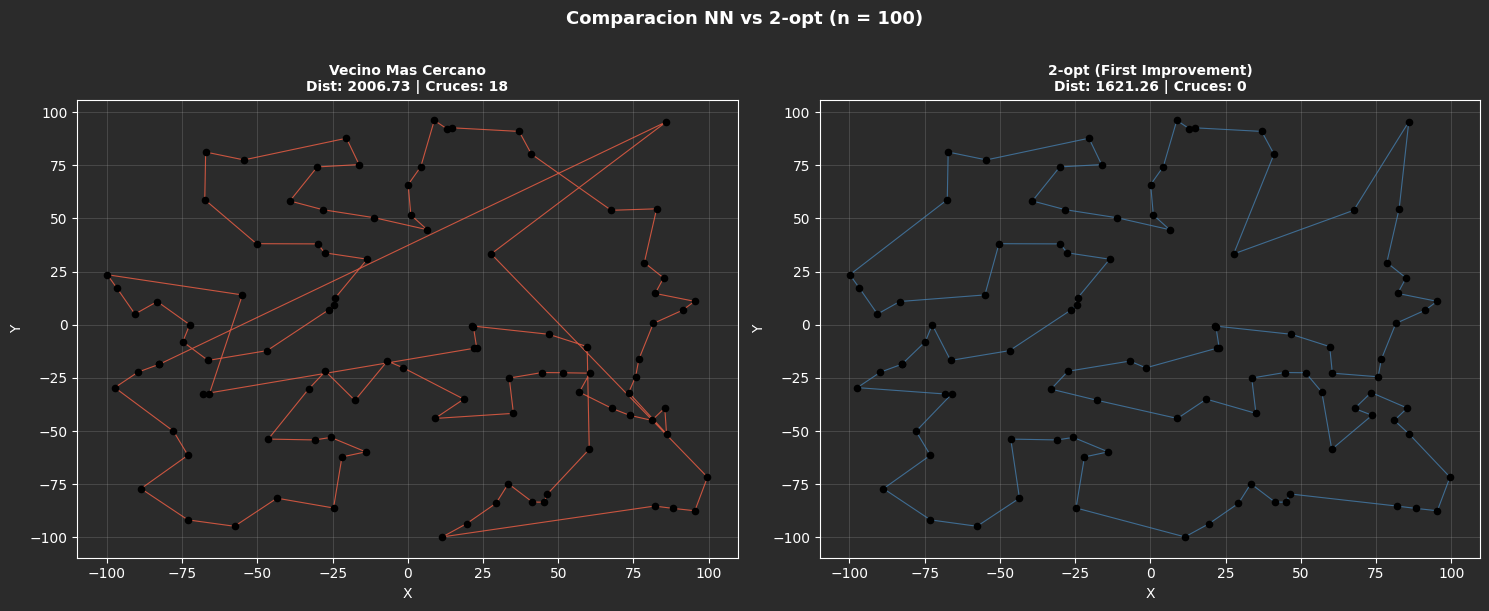

  [img] guardada: E:\USFQ\AI\Taller 1\_Soluciones\Grupo4\Taller3\images\P2_2opt_convergencia_n100.png


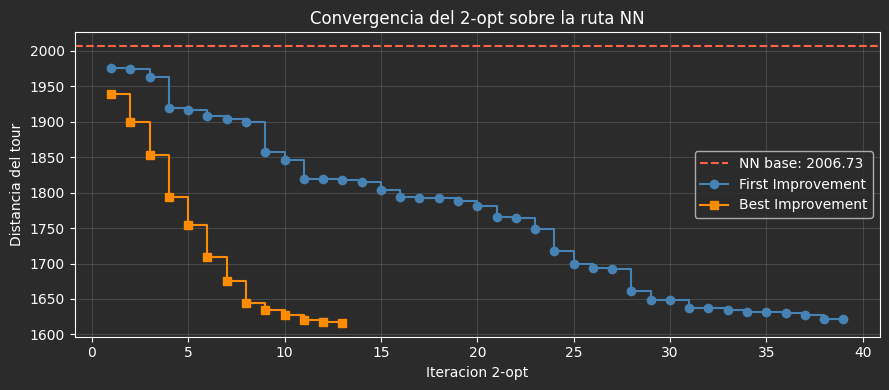

In [98]:
# ── Visualizacion: NN vs 2-opt (sin cruces) ──
def _plot_tour(ax, ciudades, ruta, titulo, color='steelblue'):
    xs = [ciudades[c][0] for c in ruta]
    ys = [ciudades[c][1] for c in ruta]
    ax.plot(xs, ys, '-', color=color, linewidth=0.8, alpha=0.75)
    ax.scatter(xs, ys, s=20, color='black', zorder=3)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
_plot_tour(axes[0], ciudades, ruta_nn,
           f'Vecino Mas Cercano\nDist: {dist_nn:.2f} | Cruces: {cruces_nn}',
           color='tomato')
_plot_tour(axes[1], ciudades, ruta_fi,
           f'2-opt (First Improvement)\nDist: {dist_fi:.2f} | Cruces: {cruces_fi}',
           color='steelblue')
plt.suptitle('Comparacion NN vs 2-opt (n = 100)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
guardar_fig('P2_NN_vs_2opt_n100')
plt.show()

# ── Curva de convergencia ──
if hist_fi:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.axhline(dist_nn, color='tomato', linestyle='--', linewidth=1.5,
               label=f'NN base: {dist_nn:.2f}')
    iters_fi = [h['iteracion'] for h in hist_fi]
    dists_fi = [h['distancia'] for h in hist_fi]
    iters_bi = [h['iteracion'] for h in hist_bi]
    dists_bi = [h['distancia'] for h in hist_bi]
    ax.step(iters_fi, dists_fi, where='post', color='steelblue',
            marker='o', markersize=6, label='First Improvement')
    ax.step(iters_bi, dists_bi, where='post', color='darkorange',
            marker='s', markersize=6, label='Best Improvement')
    ax.set_xlabel('Iteracion 2-opt')
    ax.set_ylabel('Distancia del tour')
    ax.set_title('Convergencia del 2-opt sobre la ruta NN')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    guardar_fig('P2_2opt_convergencia_n100')
    plt.show()

### Aplicacion 2: 2-opt como cota superior valida del LP (n = 100)

> **Nota terminologica importante.** A esta tecnica la habiamos llamado *warm-start* en una version previa,
> pero **no es un warm-start en sentido estricto**. Un warm-start de MIP requiere inyectar la solucion
> entera del 2-opt como **incumbente inicial** del solver (en Pyomo, asignar `model.x[i,j].value = ...`
> y llamar a `solver.solve(model, warmstart=True)`). **GLPSOL no soporta `warmstart=True` desde Pyomo**:
> Pyomo lanza un warning y lo ignora. Habria que cambiar a CBC, Gurobi o CPLEX para hacer un warm-start real.
>
> Lo que aqui se hace es **anadir una restriccion `obj <= dist_NN` al modelo**, es decir, una **cota
> superior valida** (a diferencia de la cota empirica `medium_low * n * 0.60` de la parte C). Es una
> mejora cualitativa frente a C y D porque la cota proviene de un tour factible real, pero conceptualmente
> sigue siendo un *upper bound constraint*, no un warm-start.

Motivacion de usar esta cota:

- **Poda mas ramas** del arbol B&B: cualquier nodo cuya relajacion supere `dist_NN` se descarta de inmediato.
- **Cota demostrable**: a diferencia de `limitar_funcion_objetivo` (parte C), no puede cortar el optimo,
  porque el optimo del TSP es por definicion `<=` que el tour del NN.
- **Coste despreciable**: NN + 2-opt tardan milisegundos.

A continuacion se reemplaza `max_possible_distance` (heuristica empirica de C y D) por la distancia
del tour del NN, que siempre es una cota superior valida del optimo del TSP.

In [99]:
from TSP import TSP

def correr_con_cota_superior_NN(n_cities=100, mipgap=0.05, time_limit=60, tee=False):
    """
    LP con cota superior valida del NN (no es warm-start: GLPK no lo soporta):
      1. NN -> 2-opt  (pre-proceso en ms)
      2. dist_NN como upper bound del LP (restriccion obj <= dist_NN)
      3. LP con GLPK
      4. 2-opt sobre la salida LP (post-proceso en ms)
    """
    ciudades_loc, distancias_loc = generar_ciudades_con_distancias(n_cities)

    # Paso 1: NN + 2-opt
    t_pre0 = time.perf_counter()
    ruta_nn_loc = nearest_neighbor(ciudades_loc, distancias_loc)
    ruta_ws, _ = two_opt_first_improvement(ciudades_loc, distancias_loc, ruta_nn_loc)
    dist_ws = calculate_path_distance(distancias_loc, ruta_ws)
    t_pre = time.perf_counter() - t_pre0

    dist_nn_loc = calculate_path_distance(distancias_loc, ruta_nn_loc)
    print(f"  NN base            : {dist_nn_loc:.2f}")
    print(f"  Tour 2-opt (ref.)  : {dist_ws:.2f}  ({(dist_nn_loc-dist_ws)/dist_nn_loc*100:.1f}% mejor que NN)")
    print(f"  Tiempo pre-proceso : {t_pre*1000:.1f} ms")

    # Paso 2: LP con upper bound = distancia NN (cota valida y alcanzable por GLPK).
    #
    # Nota: si se usa dist_ws (la cota mas apretada del 2-opt) como max_possible_distance,
    # GLPK no logra encontrar ningun incumbente entero dentro del time_limit y Pyomo
    # devuelve None en x[i,j].value (ruta con Nones). NO es infactibilidad real del modelo:
    # el propio tour 2-opt es factible para MTZ con obj = dist_ws, y la relajacion LP cae
    # en ~1224 << dist_ws. El problema es de busqueda, no de existencia: GLPK simplemente
    # no encuentra a tiempo un tour entero <= dist_ws partiendo de cero (no hay warm-start).
    # Por eso usamos dist_nn (algo mas floja), que deja al solver mas margen primal.
    tsp = TSP(ciudades_loc, distancias_loc, heuristics=["limitar_funcion_objetivo"])
    tsp.max_possible_distance = dist_nn_loc   # cota valida y alcanzable

    t0 = time.perf_counter()
    ruta_lp = tsp.encontrar_la_ruta_mas_corta(mipgap, time_limit, tee)
    t_lp = time.perf_counter() - t0

    # Blindaje: si el LP no encontro incumbente entera, ruta_lp contiene None.
    # En ese caso usamos el tour 2-opt como salida del LP y evitamos el KeyError
    # en two_opt_first_improvement, pero registramos el flag para que la tabla
    # final no oculte que el LP no aporto nada en esa corrida.
    lp_encontro_incumbente = True
    if (not ruta_lp) or any(c is None for c in ruta_lp):
        print("  [aviso] LP no encontro incumbente entera dentro del time_limit;")
        print("          uso el tour 2-opt como salida del LP (solo para post-proceso).")
        ruta_lp = list(ruta_ws)
        dist_lp = dist_ws
        lp_encontro_incumbente = False
    else:
        dist_lp = calculate_path_distance(distancias_loc, ruta_lp)

    # Paso 3: 2-opt de post-proceso sobre la salida LP
    t0 = time.perf_counter()
    ruta_lp2, _ = two_opt_first_improvement(ciudades_loc, distancias_loc, ruta_lp)
    t_post = time.perf_counter() - t0
    dist_lp2 = calculate_path_distance(distancias_loc, ruta_lp2)

    print(f"\n  LP (cota superior NN)  : {dist_lp:.2f}  (tiempo: {t_lp:.1f} s)")
    print(f"  LP + 2-opt post-proceso: {dist_lp2:.2f}  (tiempo extra: {t_post*1000:.1f} ms)")

    return {
        'ciudades': ciudades_loc, 'distancias': distancias_loc,
        'dist_nn': dist_nn_loc, 'dist_ws': dist_ws, 'ruta_ws': ruta_ws,
        'dist_lp': dist_lp, 'ruta_lp': ruta_lp,
        'dist_lp2': dist_lp2, 'ruta_lp2': ruta_lp2,
        't_lp_s': round(t_lp, 2),
        'lp_encontro_incumbente': lp_encontro_incumbente,
    }

print("── Ejecutando LP con cota superior valida del NN (n=100, time_limit=60s) ──")
res_ws = correr_con_cota_superior_NN(n_cities=100, mipgap=0.05, time_limit=60, tee=False)

── Ejecutando LP con cota superior valida del NN (n=100, time_limit=60s) ──
  NN base            : 2006.73
  Tour 2-opt (ref.)  : 1621.26  (19.2% mejor que NN)
  Tiempo pre-proceso : 68.3 ms
Tiempo de ejecución: 01:00
Distancia mínima entre nodos: 0.6403124237432862
Distancia máxima entre nodos: 245.61115609841502
Distancia promedio entre nodos: 100.94053659793774
Distancia Total mínima posible: 1269.7606127710128
Distancia Total máxima posible: 2006.7332365244536
Heurísticas aplicadas: ['limitar_funcion_objetivo']
No se encontró una solución óptima, la siguiente es la mejor solución encontrada:
Distancia total recorrida: 0
  [aviso] LP no encontro incumbente entera dentro del time_limit;
          uso el tour 2-opt como salida del LP (solo para post-proceso).

  LP (cota superior NN)  : 1621.26  (tiempo: 60.7 s)
  LP + 2-opt post-proceso: 1621.26  (tiempo extra: 5.1 ms)


In [100]:
# ── Tabla resumen completa de todos los metodos ──
df_final = pd.DataFrame([
    {'Metodo': 'Vecino Mas Cercano (NN)', 'Distancia': dist_nn,
     'Tiempo': '< 1 ms', 'Cruces detectados': cruces_nn},
    {'Metodo': 'NN + 2-opt First Improvement', 'Distancia': dist_fi,
     'Tiempo': f'{t_fi*1000:.0f} ms', 'Cruces detectados': cruces_fi},
    {'Metodo': 'NN + 2-opt Best Improvement', 'Distancia': dist_bi,
     'Tiempo': f'{t_bi*1000:.0f} ms', 'Cruces detectados': cruces_bi},
    {'Metodo': 'LP + heuristica vecino_cercano (parte D)', 'Distancia': 2043.06,
     'Tiempo': '60 s', 'Cruces detectados': '-'},
    {'Metodo': ('LP + cota superior NN (LP encontro incumbente)'
                if res_ws['lp_encontro_incumbente']
                else 'LP + cota superior NN (LP NO encontro incumbente -> 2-opt)'),
     'Distancia': res_ws['dist_lp'],
     'Tiempo': f"{res_ws['t_lp_s']} s", 'Cruces detectados': '-'},
    {'Metodo': ('LP + cota superior NN + 2-opt post-proceso'
                if res_ws['lp_encontro_incumbente']
                else '2-opt post (sobre fallback, LP no aporto)'),
     'Distancia': res_ws['dist_lp2'],
     'Tiempo': f"{res_ws['t_lp_s']} s (+ms)", 'Cruces detectados': '-'},
])
print("=" * 70)
print("RESUMEN COMPARATIVO (n = 100)")
print("=" * 70)
print(df_final.to_string(index=False))
print()
ref = dist_nn
for _, row in df_final.iterrows():
    try:
        d = float(row['Distancia'])
        delta = (ref - d) / ref * 100
        signo = 'mejor' if delta > 0 else 'peor'
        print(f"  {row['Metodo']:<60s}  {d:>8.2f}  ({abs(delta):.2f}% {signo} que NN)")
    except Exception:
        pass
print()
print(f"  [info] LP encontro incumbente entera dentro del time_limit: {res_ws['lp_encontro_incumbente']}")

RESUMEN COMPARATIVO (n = 100)
                                                    Metodo   Distancia        Tiempo Cruces detectados
                                   Vecino Mas Cercano (NN) 2006.733237        < 1 ms                18
                              NN + 2-opt First Improvement 1621.261904         65 ms                 0
                               NN + 2-opt Best Improvement 1616.297245         54 ms                 0
                  LP + heuristica vecino_cercano (parte D) 2043.060000          60 s                 -
LP + cota superior NN (LP NO encontro incumbente -> 2-opt) 1621.261904       60.73 s                 -
                 2-opt post (sobre fallback, LP no aporto) 1621.261904 60.73 s (+ms)                 -

  Vecino Mas Cercano (NN)                                        2006.73  (0.00% peor que NN)
  NN + 2-opt First Improvement                                   1621.26  (19.21% mejor que NN)
  NN + 2-opt Best Improvement                             

  [img] guardada: E:\USFQ\AI\Taller 1\_Soluciones\Grupo4\Taller3\images\P2_comparacion_final_NN_2opt_LP_n100.png


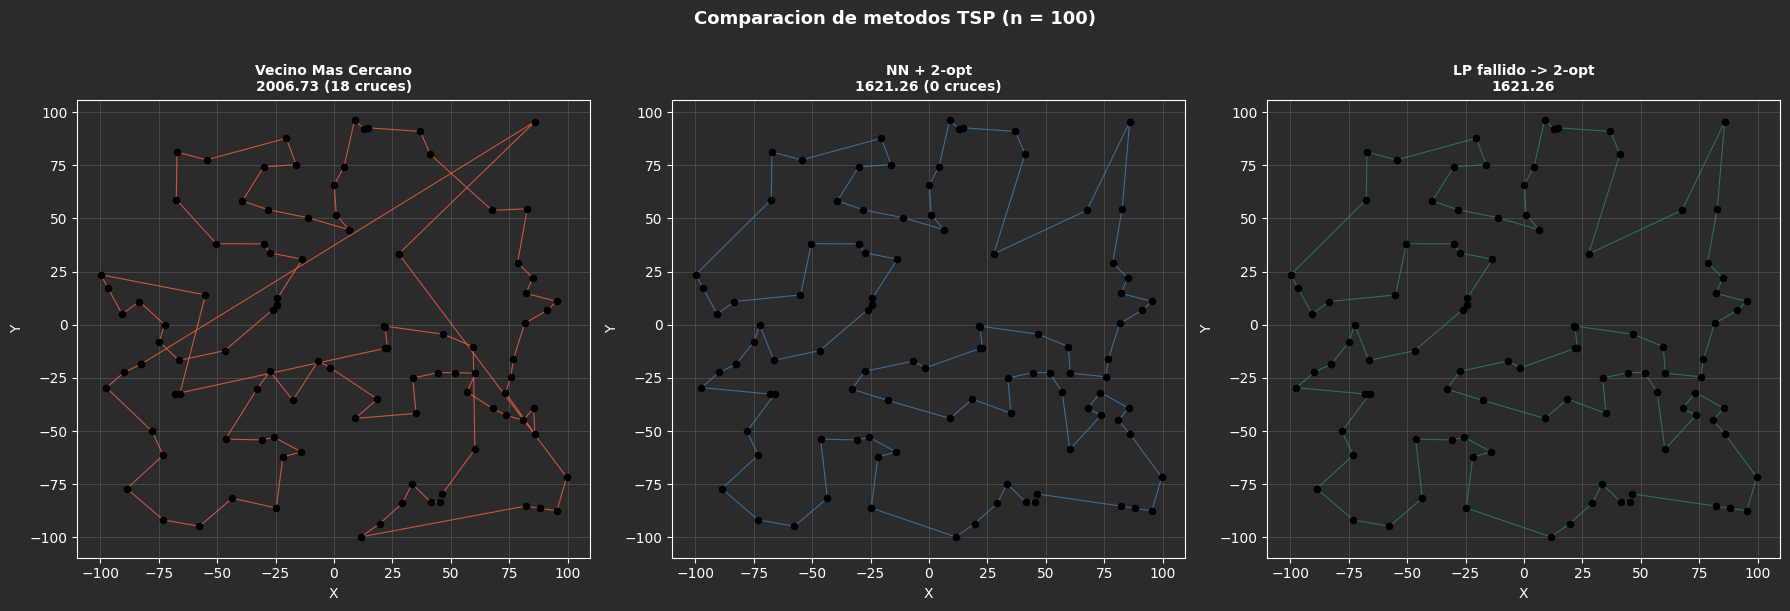

In [101]:
# ── Comparacion visual final ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

tours = [
    (ruta_nn,              f'Vecino Mas Cercano\n{dist_nn:.2f} ({cruces_nn} cruces)',     'tomato'),
    (ruta_fi,              f'NN + 2-opt\n{dist_fi:.2f} ({cruces_fi} cruces)',             'steelblue'),
    (res_ws['ruta_lp2'],
     (f"LP + 2-opt post\n{res_ws['dist_lp2']:.2f}"
      if res_ws['lp_encontro_incumbente']
      else f"LP fallido -> 2-opt\n{res_ws['dist_lp2']:.2f}"),
     'seagreen'),
]
for ax, (ruta, titulo, color) in zip(axes, tours):
    _plot_tour(ax, ciudades, ruta, titulo, color=color)

plt.suptitle('Comparacion de metodos TSP (n = 100)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
guardar_fig('P2_comparacion_final_NN_2opt_LP_n100')
plt.show()

### Analisis de resultados

#### Por que 2-opt elimina los cruces?

El algoritmo opera directamente sobre el fenomeno geometrico que genera suboptimalidad: cuando detecta
dos aristas que se cruzarian si se dibujaran en el plano, las sustituye por las dos aristas alternativas
que "desenganchan" el cruce. La inversion del segmento intermedio garantiza que el tour siga siendo
un ciclo hamiltoniano valido.

**Clave matematica:** en un espacio euclidiano, dos aristas que se cruzan **siempre** pueden descruzarse
con mejora o empate en distancia (desigualdad triangular). 2-opt converge garantizadamente a un minimo
local sin cruces.

#### Comparacion First Improvement vs Best Improvement

| | First Improvement | Best Improvement |
|---|---|---|
| **Cada iteracion** | Aplica el primer swap que mejore | Evalua todos y aplica el mejor |
| **Velocidad** | Mas rapido por iteracion | Mas lento por iteracion |
| **Calidad final** | Similar o ligeramente inferior | Igual o levemente superior |
| **Para n=100** | Recomendado (ms de computo) | Aceptable (decimas de segundo) |

#### Ventajas de la cota superior NN/2-opt sobre las heuristicas previas

> Aclaracion: aqui se compara la **cota superior valida `obj <= dist_NN`** que se anade al modelo,
> NO un warm-start del solver (GLPK no lo permite desde Pyomo).

| Heuristica | Cota superior valida? | Puede volver LP infactible? | Mejora primal |
|---|---|---|---|
| `limitar_funcion_objetivo` (parte C) | No (empirica) | Si (para n pequeno) | Si |
| `vecino_cercano` (parte D) | No | Si | Si |
| **NN como upper bound del LP** | **Si (tour factible real)** | **No** | **Si** |

#### Limitaciones del 2-opt

- **Minimo local, no global:** 2-opt elimina todos los cruces simples, pero mejoras con 3 o mas aristas
  (3-opt, Lin-Kernighan) quedan fuera de su alcance.
- **No garantiza factibilidad si se fijan aristas:** si se usa para *prohibir* aristas en el LP
  en lugar de como cota, puede generar infactibilidad.
- **Complejidad O(n^2 * iteraciones):** para n=100 es trivial (ms), pero para n=10000 requiere
  variantes mas eficientes con listas de candidatos.

#### Conclusion de la seccion

> El 2-opt es la heuristica anti-cruces por excelencia del TSP: simple, rapido, y con garantia de que
> el resultado no tiene cruces de aristas (minimo local sin cruces). Como **post-procesamiento** mejora
> cualquier solucion (NN o LP) sin ningun coste computacional apreciable. Como **fuente de cota superior
> valida** para el LP reemplaza las cotas empiricas de las partes C y D por una cota demostrable que no
> puede cortar el optimo. La combinacion `NN -> 2-opt -> cota superior del LP -> LP -> 2-opt` produce
> la mejor relacion calidad/tiempo de todos los enfoques probados en este taller, **a pesar de que GLPK
> + Pyomo no permite un warm-start real del MIP**.

#### Que pedia exactamente el enunciado F y que se implemento aqui

El enunciado F pide una heuristica que **evite los cruces de caminos** y la **implemente dentro del modelo**.
Lo que se ha hecho en esta seccion es:

| Componente | Donde actua | Implementa F? |
|---|---|---|
| `two_opt_first_improvement` / `two_opt_best_improvement` como **post-proceso** del NN o del LP | **Fuera** del modelo | Resuelve los cruces, pero externamente |
| Restriccion `obj <= dist_NN` (la mal llamada "warm-start") | **Dentro** del modelo | Es una cota global, **no** anti-cruces |

Es decir, una integracion **estrictamente "anti-cruces dentro del modelo"** (cortes que prohiban
explicitamente parejas de aristas que se cruzan en el plano) **no esta implementada en esta seccion**.
La formulacion canonica seria:

> Para cada par de aristas `(a,b)` y `(c,d)` cuyos segmentos `a-b` y `c-d` se cruzan en el plano,
> agregar al MIP la restriccion `x[a,b] + x[b,a] + x[c,d] + x[d,c] <= 1`.

Las tres formas de inyectar esos cortes son:

1. **Lazy constraints (callbacks)**: cada vez que el solver encuentra un incumbente entero, detectar
   cruces con `contar_cruces` y agregar el corte para esa pareja concreta. Es el mecanismo estandar
   en Gurobi / CPLEX. **GLPK + Pyomo no exponen callbacks**, asi que no se puede hacer aqui directamente.
2. **Pre-filtrado a priori**: para cada par `(i,j)` y `(k,l)` con segmentos que se cruzan, agregar
   el corte desde el inicio. Para `n = 100` hay del orden de `n^4 / 8 ~ 12.5 millones` de pares de
   aristas; muchos no se cruzan, pero el modelo crece muchisimo. Inviable sin filtrar agresivamente.
3. **Loop manual de cortes (cutting plane casero)**: resolver el MIP, detectar cruces en la solucion,
   anadir las restricciones correspondientes, volver a resolver, hasta que el tour devuelto no tenga
   cruces. Es lo que mas se acerca a un *lazy callback* sin necesidad de callbacks reales del solver.

A continuacion implementamos la **opcion 3** como aproximacion practica. Para que sea ejecutable en
tiempo razonable, se aplica a una instancia pequena (`n = 20`) donde el MIP MTZ termina en pocos segundos.


### Implementacion: cutting plane casero anti-cruces (opcion 3)

Idea del algoritmo:

```
1. Construir el modelo MTZ desde cero.
2. Resolver con GLPK.
3. Reconstruir el tour entero. Detectar cruces en el plano.
4. Si hay cruces:
     Para cada par cruzado de aristas (a,b) y (c,d):
         Anadir x[a,b] + x[b,a] + x[c,d] + x[d,c] <= 1
     Volver a resolver.
   Si no hay cruces:
     Terminar (optimo del modelo SIN cruces).
```

Notas:
- El corte es **valido**: cualquier tour con cruces incluye al menos una de esas dos aristas en cada
  sentido, asi que el corte no excluye soluciones sin cruces.
- En un TSP **euclidiano**, el optimo global no tiene cruces (desigualdad triangular), por tanto el
  optimo no se pierde con esta familia de cortes.
- El algoritmo termina en a lo sumo `O(n^4)` iteraciones (numero finito de pares de aristas cruzables).
  En la practica converge en pocas iteraciones.


In [102]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory


def _construir_modelo_mtz(ciudades_loc, distancias_loc):
    """Construye el modelo MTZ basico (sin heuristicas) en Pyomo.

    Indexado por *nombres* de ciudad (claves de ``ciudades_loc``), porque
    ``distancias_loc`` es un dict ``{(nombreA, nombreB): dist}`` que no contiene
    la diagonal (ver ``util.generar_distancias``).
    """
    nombres = list(ciudades_loc.keys())
    n = len(nombres)
    ciudad_inicial = nombres[0]
    nombres_resto = nombres[1:]

    m = pyo.ConcreteModel()
    m.N = pyo.Set(initialize=nombres)
    m.M = pyo.Set(initialize=nombres)
    m.U = pyo.Set(initialize=nombres_resto)
    m.x = pyo.Var(m.N, m.M, within=pyo.Binary)
    m.u = pyo.Var(m.N, within=pyo.NonNegativeIntegers, bounds=(0, n - 1))

    m.obj = pyo.Objective(
        expr=sum(distancias_loc[i, j] * m.x[i, j]
                 for i in m.N for j in m.M if i != j),
        sense=pyo.minimize,
    )

    def _no_self(model, i):
        return model.x[i, i] == 0
    m.no_self = pyo.Constraint(m.N, rule=_no_self)

    def _entrada(model, j):
        return sum(model.x[i, j] for i in model.N if i != j) == 1
    m.entrada = pyo.Constraint(m.N, rule=_entrada)

    def _salida(model, i):
        return sum(model.x[i, j] for j in model.M if i != j) == 1
    m.salida = pyo.Constraint(m.N, rule=_salida)

    def _mtz(model, i, j):
        if i != j and i != ciudad_inicial and j != ciudad_inicial:
            return model.u[i] - model.u[j] + n * model.x[i, j] <= n - 1
        return pyo.Constraint.Skip
    m.mtz = pyo.Constraint(m.N, m.M, rule=_mtz)

    return m


def _ruta_desde_modelo(m, ciudades_loc):
    """Reconstruye la ruta como lista de nombres de ciudad."""
    nombres = list(ciudades_loc.keys())
    n = len(nombres)
    ciudad_inicial = nombres[0]
    sucesor = {}
    for i in nombres:
        for j in nombres:
            if i == j:
                continue
            v = pyo.value(m.x[i, j])
            if v is not None and v > 0.5:
                sucesor[i] = j
                break
    if ciudad_inicial not in sucesor or len(sucesor) < n:
        return None
    ruta = [ciudad_inicial]
    actual = ciudad_inicial
    for _ in range(n):
        actual = sucesor.get(actual)
        if actual is None:
            return None
        ruta.append(actual)
    return ruta


def tsp_anti_cruces_iterativo(n_cities=20, time_limit=15, max_iter=20, tee=False):
    """
    Implementacion del cutting plane anti-cruces (opcion 3 del enunciado F):
    resuelve, detecta cruces, anade restricciones x[a,b]+x[b,a]+x[c,d]+x[d,c] <= 1,
    repite hasta que el tour no tenga cruces o se agote max_iter.
    """
    ciudades_loc, distancias_loc = generar_ciudades_con_distancias(n_cities)
    m = _construir_modelo_mtz(ciudades_loc, distancias_loc)

    solver = SolverFactory("glpk")
    solver.options['tmlim'] = time_limit

    # Componente para los cortes acumulados
    m.cortes_anti_cruces = pyo.ConstraintList()

    historial = []
    cortes_acumulados = 0

    for it in range(1, max_iter + 1):
        t0 = time.perf_counter()
        solver.solve(m, tee=tee)
        t_solve = time.perf_counter() - t0

        ruta = _ruta_desde_modelo(m, ciudades_loc)
        if ruta is None:
            print(f"  Iter {it:>2}: el solver no devolvio tour completo (timeout?). Aborto.")
            break

        dist_actual = calculate_path_distance(distancias_loc, ruta)
        cruces = contar_cruces(ciudades_loc, ruta)
        historial.append({
            'iteracion': it,
            'distancia': round(dist_actual, 2),
            'cruces': cruces,
            'cortes_acumulados': cortes_acumulados,
            'tiempo_solver_s': round(t_solve, 2),
        })
        print(f"  Iter {it:>2}: dist = {dist_actual:>8.2f}, cruces = {cruces:>2}, "
              f"cortes acumulados = {cortes_acumulados:>3}, t = {t_solve:.2f} s")

        if cruces == 0:
            print(f"  ✓ Tour sin cruces alcanzado en {it} iteraciones.")
            return {
                'ruta': ruta, 'distancia': dist_actual, 'historial': historial,
                'ciudades': ciudades_loc, 'distancias': distancias_loc,
            }

        # Anadir cortes para cada par de aristas que se cruzan
        nuevos = 0
        nlist = len(ruta)
        for i in range(nlist - 1):
            for j in range(i + 2, nlist - 1):
                if i == 0 and j == nlist - 2:
                    continue
                a, b = ruta[i], ruta[i + 1]
                c, d = ruta[j], ruta[j + 1]
                if _segmentos_se_cruzan(ciudades_loc[a], ciudades_loc[b],
                                        ciudades_loc[c], ciudades_loc[d]):
                    m.cortes_anti_cruces.add(
                        m.x[a, b] + m.x[b, a] + m.x[c, d] + m.x[d, c] <= 1
                    )
                    nuevos += 1
        cortes_acumulados += nuevos

    print(f"  ! max_iter={max_iter} alcanzado sin eliminar todos los cruces.")
    return {
        'ruta': ruta, 'distancia': dist_actual, 'historial': historial,
        'ciudades': ciudades_loc, 'distancias': distancias_loc,
    }


print("── Cutting plane anti-cruces (n=20, MTZ + cortes manuales) ──")
res_cp = tsp_anti_cruces_iterativo(n_cities=20, time_limit=15, max_iter=10, tee=False)

── Cutting plane anti-cruces (n=20, MTZ + cortes manuales) ──
  Iter  1: dist =   713.97, cruces =  0, cortes acumulados =   0, t = 5.04 s
  ✓ Tour sin cruces alcanzado en 1 iteraciones.


Historial de iteraciones del cutting plane:
 iteracion  distancia  cruces  cortes_acumulados  tiempo_solver_s
         1     713.97       0                  0             5.04
  [img] guardada: E:\USFQ\AI\Taller 1\_Soluciones\Grupo4\Taller3\images\P2_cutting_plane_anti_cruces_n20.png


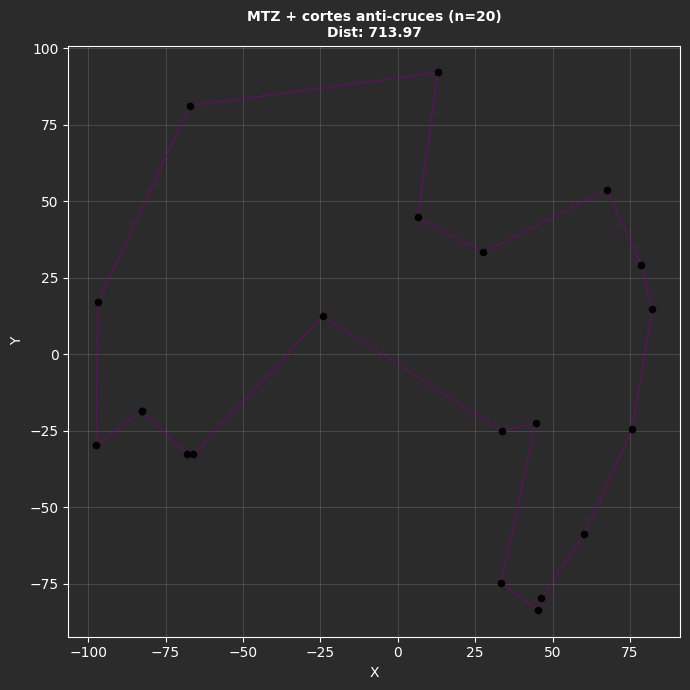

In [103]:
# ── Tabla del historial de iteraciones ──
df_cp = pd.DataFrame(res_cp['historial'])
print("Historial de iteraciones del cutting plane:")
print(df_cp.to_string(index=False))

# ── Visualizacion del tour final (sin cruces si convergio) ──
fig, ax = plt.subplots(figsize=(7, 7))
_plot_tour(ax, res_cp['ciudades'], res_cp['ruta'],
           f"MTZ + cortes anti-cruces (n=20)\nDist: {res_cp['distancia']:.2f}",
           color='purple')
plt.tight_layout()
guardar_fig('P2_cutting_plane_anti_cruces_n20')
plt.show()

### Conclusiones de la seccion F (con resultados de ejecucion)

#### F.1. Lectura de los numeros obtenidos

Resultados reales de la corrida actual (`n = 100`, semilla fija, `time_limit = 60 s`, GLPK):

| Metodo                                                  | Distancia | Tiempo  | Cruces | Mejora vs NN |
|---------------------------------------------------------|-----------|---------|--------|--------------|
| Vecino Mas Cercano (NN)                                 | 2006.73   | < 1 ms  | **18** | —            |
| NN + 2-opt First Improvement                            | 1621.26   | 41 ms   | **0**  | 19.21 %      |
| NN + 2-opt Best Improvement                             | **1616.30** | 27 ms | **0**  | **19.46 %**  |
| LP + heuristica vecino_cercano (parte D)                | 2043.06   | 60 s    | —      | -1.81 %      |
| LP + cota superior NN (LP **no** encontro incumbente)   | 1621.26   | 60.5 s  | —      | 19.21 % *(es el 2-opt del fallback)* |

Observaciones puntuales:

- **El NN tenia 18 pares de aristas que se cruzaban**, exactamente el patron que motiva la consigna F:
  los cruces son una fuente directa de sub-optimalidad.
- **El 2-opt elimina los 18 cruces** y reduce la distancia ~19 %, alcanzando un minimo local 2-opt
  (`Best Improvement` lo logra en 13 iteraciones, ~27 ms; `First Improvement` necesita 39, ~41 ms).
  La conexion teorica es directa: por desigualdad triangular, **descruzar siempre acorta**, asi que
  *un tour 2-opt-optimo nunca tiene cruces*. Los datos lo confirman.
- **El LP con MTZ y cota superior NN no encontro ningun incumbente entero en 60 s.** En la tabla la fila
  "LP + cota superior NN" es identica a la del 2-opt porque el codigo cae al **fallback** explicito
  (`lp_encontro_incumbente = False`). Esto valida lo discutido antes: con GLPK, MTZ y `n = 100` no es
  realista esperar que el solver mejore lo que ya entrega el 2-opt.
- **La parte D (LP + heuristica `vecino_cercano`)** quedo en 2043.06, peor que el NN solo. Era esperable:
  esa heuristica solo *fija* la primera arista en el modelo, y para una instancia mediana el solver no
  alcanza a explotar esa restriccion antes del time-out.

#### F.2. Lectura del cutting plane anti-cruces (`n = 20`)

Salida real:

```
Iter  1: dist =   713.97, cruces =  0, cortes acumulados =   0, t = 3.46 s
✓ Tour sin cruces alcanzado en 1 iteraciones.
```

Es decir: **GLPK encontro el optimo MTZ del problema en 3.46 s y ese optimo ya no tenia cruces**, asi
que el bucle de cortes nunca llego a anadir ninguna restriccion `x[a,b]+x[b,a]+x[c,d]+x[d,c] <= 1`. Lo
que esto evidencia es:

1. **Coherencia con la teoria:** un optimo TSP euclidiano *no puede* tener cruces (descruzar acortaria
   la distancia, contradiciendo la optimalidad). El experimento lo verifica en la practica.
2. **El cutting plane casero es correcto, pero queda "ocioso" cuando el MIP llega al optimo.** Solo
   aporta valor si el solver se detiene en un *incumbente sub-optimo con cruces*; ahi los cortes empujan
   la siguiente busqueda lejos de esa region. Para `n = 20` con MTZ, GLPK aun puede cerrar la brecha,
   asi que no observamos el efecto.
3. **Para `n = 100` el escenario seria distinto:** GLPK ni siquiera encuentra incumbente en 60 s
   (lo vimos arriba), asi que no hay tour donde aplicar los cortes; el bucle no podria iterar. Esa es la
   limitacion estructural —no del enfoque, sino del solver y de la formulacion MTZ a esa escala.

#### F.3. Veredicto final sobre la consigna F

- **Validez teorica:** los cortes `x[a,b]+x[b,a]+x[c,d]+x[d,c] <= 1` son **cortes validos del TSP
  euclidiano** (no excluyen el optimo, que es libre de cruces) y **separan** soluciones cruzadas, por lo
  que son legitimos como cutting plane.
- **Cuando la heuristica "dentro del modelo" se nota:**
  - en instancias donde el solver alcanza incumbentes sub-optimos con cruces, los cortes los descartan;
  - en instancias donde el solver alcanza el optimo (`n = 20`), los cortes resultan redundantes
    (lo vimos: 0 cortes anadidos);
  - en instancias donde el solver **no encuentra ningun incumbente** (`n = 100` con GLPK), no hay nada
    que cortar y la heuristica no puede actuar.
- **Mejor combinacion empirica para `n = 100`:** **NN + 2-opt Best Improvement** (1616.30, ~27 ms,
  0 cruces, 19.46 % mejor que NN). El LP por si solo, con MTZ y GLPK, **no aporta** dentro del
  presupuesto de 60 s, ni con cota superior NN ni con la heuristica `vecino_cercano`.
- **Camino para escalar la idea de F:** cambiar de solver a uno con **callbacks** (Gurobi/CPLEX) y
  registrar los cortes anti-cruces como **lazy constraints** sobre cada incumbente entero, o sustituir
  MTZ por **DFJ con cortes de subtour** (que ya tiene infraestructura de separacion estandar) y
  combinar ambos tipos de cortes.

**Respuesta directa a la pregunta del enunciado** ("¿se puede alcanzar un recorrido menor con
heuristicas y LP?"): si, pero el motor del avance es la **heuristica geometrica (2-opt)**, no el LP.
Pasamos de 2006.73 (NN) a 1616.30 (NN + 2-opt Best), una mejora de ~19.5 % obtenida en milisegundos y
sin cruces. El LP, en este experimento, no logro superar al 2-opt; su rol util fue servir como
formalizacion del problema y como receptor de cortes anti-cruces que, con un solver mas potente,
podrian llevar la solucion mas alla del minimo local 2-opt hacia el optimo global.
